## AI 헬스케어 첫 번째 미니 프로젝트
흡연 여부 데이터 분석을 통한 건강 인사이트 도출에 오신 여러분 환영합니다!  
우리는 흡연 관련 건강 데이터를 분석하여 시각화하고, 다양한 가설을 검증해보는 과정을 함께 할 것입니다.  
A부터 Z까지 친절하게 안내해 드릴 예정이니, 천천히 따라해 보세요!

### 🚬 흡연 여부 데이터 분석하기
최근 여러 기관에서는 흡연이 개인의 건강에 미치는 영향을 정확히 파악하고,
이를 기반으로 예방 중심의 건강관리 정책을 수립하려는 노력을 강화하고 있습니다.

하지만 “흡연 여부”를 직접 조사하는 것은 현실적으로 쉽지 않습니다.
이에 따라, 건강검진 데이터를 통해 흡연 여부를 데이터 기반으로 추정하고,
흡연자와 비흡연자 간의 생체·건강 지표 차이를 검증하려는 프로젝트가 시작되었습니다.

여러분은 이 프로젝트의 데이터 분석가이자 AI 엔지니어로 참여하게 되었습니다.
주어진 데이터에는 개인의 건강검진 결과(혈압, 혈당, 콜레스테롤, BMI 등)와 흡연 여부(label = 0 또는 1)가 포함되어 있습니다.

이제 여러분의 역할은 흡연 여부 데이터의 특성을 분석하고 시각화하며, 통계적 검정을 통해 변수 간 관계를 규명하는 것입니다.
시작해봅시다 !

#### 🎯 프로젝트 목표

- 흡연자와 비흡연자 간의 건강 지표 차이 분석
- 주요 변수들의 분포, 상관관계, 통계적 유의성 검증
- 시각화를 통한 데이터 인사이트 도출
- 추후 흡연 여부 예측 모델 개발을 위한 기초 분석 기반 마련



---



## 0. 라이브러리 불러오기
데이터 분석에 필요한 라이브러리를 먼저 불러옵시다! (ex. pandas, matplotlib, seaborn 등)

##### **[TODO] 라이브러리 로딩**
-  `pandas` 라이브러리를 `pd` 라는 별칭으로 불러오세요.
-  `matplotlib` 라이브러리를 `plt` 라는 별칭으로 불러오세요.
-  `seaborn` 라이브러리를 `sns` 라는 별칭으로 불러오세요.

## ✏️ 나눔고딕 폰트 설치

In [ ]:
# 코랩(Colab)에서 한글을 지원하는 나눔고딕 폰트를 설치하고 matplotlib에 적용합니다.
!apt-get -qq -y install fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정 완료! 이제 그래프에 한글을 사용할 수 있습니다.")

한글 폰트 설정 완료! 이제 그래프에 한글을 사용할 수 있습니다.


In [ ]:
# 나눔폰트 설치 (Linux 명령어)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

print("폰트 설치가 완료되었습니다. 반드시 '런타임 > 세션 다시 시작'을 누르고 아래 코드를 실행하세요!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [ ]:
!ls /usr/share/fonts/truetype/nanum

NanumBarunGothicBold.ttf   NanumGothicCoding.ttf  NanumSquareB.ttf
NanumBarunGothic.ttf	   NanumGothic.ttf	  NanumSquareRoundB.ttf
NanumGothicBold.ttf	   NanumMyeongjoBold.ttf  NanumSquareRoundR.ttf
NanumGothicCodingBold.ttf  NanumMyeongjo.ttf	  NanumSquareR.ttf


## 📚 라이브러리 설치

In [ ]:
# 필요한 라이브러리들 불러오기
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns

---
## 1. 데이터 불러오기
모든 데이터 분석의 시작은 '데이터 불러오기' 부터 입니다!

**(예시)**
- csv : pd.read_csv("파일이름. csv")
- txt : pd.read_csv("파일이름. csv", sep="구분자")
- xlsx : pd.read_excel('파일이름.xlsx')
- pickle : pd.read_pickle("파일이름.pkl")

[참고] pickle은 파이썬의 모든 객체를 파일로 저장할 수 있는 방법으로 DataFrame,List,Dict 등 모든 객체 저장 가능
*(특히 sklearn라이브러리를 통해 모델을 학습시키고, 저장할 때 많이 사용됩니다)*

##### **[TODO] 데이터 로딩**
- Pandas의 `read_csv()` 함수를 활용하여 `smoking_health_data.csv` 파일을 `health_data` 변수에 저장하세요.
- `health_data` 데이터프레임의 크기(shape)를 확인하세요.

In [ ]:
# CSV 불러오기
health_data = pd.read_csv("smoking_health_data.csv")

# 데이터 크기 확인
health_data.shape

(7000, 18)

---
## 2. 기본 정보 확인 및 데이터 정제
데이터 정제란 ? 결측치, 이상치 등을 제거하여 데이터 분석 결과가 왜곡 되는 문제를 방지하기 위한 정제 과정입니다.

##### **[TODO] 기본 정보 확인하기**
- `health_data` 데이터의 정보를 확인해보세요.
    -   **`info()`**: 각 컬럼의 데이터 타입, Non-null 값 개수 등을 확인합니다.
    -   **`describe()`**: 숫자형 컬럼의 통계 요약 (평균, 표준편차, 최솟값, 최댓값 등)을 확인합니다.
    -   **`head()`**: 데이터의 상위 5행을 확인하여 샘플 데이터를 살펴봅니다.
    -   **`tail()`**: 데이터의 하위 5행을 확인합니다.

In [ ]:
# info(): 각 컬럼의 데이터 타입, Non-null 값 개수 등을 확인
health_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        7000 non-null   object 
 1   나이        7000 non-null   int64  
 2   키(cm)     7000 non-null   int64  
 3   몸무게(kg)   7000 non-null   int64  
 4   BMI       7000 non-null   float64
 5   시력        6860 non-null   float64
 6   충치        7000 non-null   int64  
 7   공복 혈당     6860 non-null   float64
 8   혈압        6860 non-null   float64
 9   중성 지방     6860 non-null   float64
 10  혈청 크레아티닌  7000 non-null   float64
 11  콜레스테롤     7000 non-null   int64  
 12  고밀도지단백    7000 non-null   int64  
 13  저밀도지단백    7000 non-null   int64  
 14  헤모글로빈     7000 non-null   float64
 15  요 단백      7000 non-null   int64  
 16  간 효소율     7000 non-null   float64
 17  label     7000 non-null   int64  
dtypes: float64(8), int64(9), object(1)
memory usage: 984.5+ KB


In [ ]:
# describe(): 숫자형 컬럼의 통계 요약(평균, 표준편차, 최솟값, 최댓값 등)을 확인
health_data.describe()

,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
count,7000.000000,7000.000000,7000.000000,7000.000000,6860.000000,7000.000000,6860.000000,6860.000000,6860.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,43.973571,164.781429,65.932857,24.144423,1.011414,0.227429,99.307289,45.555102,127.028134,0.884900,197.276571,57.355429,115.346857,14.631914,1.083857,1.144696,0.367286
std,12.063793,9.170213,12.978702,3.501945,0.430137,0.419202,21.190058,8.831564,73.219161,0.241523,36.306494,14.506945,41.788153,1.540907,0.392051,0.432735,0.482100
min,20.000000,135.000000,30.000000,14.270000,0.100000,0.000000,57.000000,14.000000,21.000000,0.100000,86.000000,18.000000,1.000000,4.900000,1.000000,0.140000,0.000000
25%,35.000000,160.000000,55.000000,21.600000,0.800000,0.000000,89.000000,40.000000,74.000000,0.800000,173.000000,47.000000,92.000000,13.600000,1.000000,0.840000,0.000000
50%,40.000000,165.000000,65.000000,23.880000,1.000000,0.000000,96.000000,45.000000,107.000000,0.900000,195.000000,55.000000,113.000000,14.800000,1.000000,1.100000,0.000000
75%,50.000000,170.000000,75.000000,26.120000,1.200000,0.000000,104.000000,50.000000,161.000000,1.000000,219.000000,66.000000,136.000000,15.700000,1.000000,1.380000,1.000000
max,85.000000,190.000000,130.000000,42.450000,9.900000,1.000000,386.000000,91.000000,399.000000,10.000000,395.000000,157.000000,1340.000000,20.900000,5.000000,5.670000,1.000000


In [ ]:
# head(): 데이터의 상위 5행 출력(샘플 확인)
health_data.head()

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0


In [ ]:
# tail(): 데이터의 하위 5행 출력
health_data.tail()

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
6995,TRAIN_6995,25,170,65,22.49,1.50,0,87.0,45.0,141.0,1.2,184,44,112,14.9,1,1.50,0
6996,TRAIN_6996,60,165,65,23.88,0.90,0,87.0,45.0,82.0,0.9,184,64,103,14.3,1,1.47,1
6997,TRAIN_6997,40,180,100,30.86,1.20,0,97.0,44.0,87.0,0.9,178,54,107,15.6,1,1.00,0
6998,TRAIN_6998,60,150,55,24.44,0.60,0,89.0,57.0,161.0,0.6,157,49,76,14.4,1,1.00,0
6999,TRAIN_6999,50,165,65,23.88,0.65,0,104.0,47.0,124.0,0.8,251,56,170,13.6,1,0.81,0


##### **[TODO] BMI를 기준으로 체중 상태 구분 컬럼 추가**
- `health_data` 데이터프레임에 'BMI 구간'을 기준으로 체중 상태를 나타내는 새로운 컬럼을 추가하세요.

  - 저체중 (18.5 미만)
  - 정상 (18.5 이상 ~ 22.9 이하)
  - 비만전단계 (23 이상 ~ 24.9 이하)
  - 1단계 비만 (25 이상 ~ 29.9 이하)
  - 2단계 비만 (30 이상 ~ 34.9 이하)
  - 3단계 비만 (35 이상)

In [ ]:
# BMI를 기준으로 체중 상태 구분 컬럼 추가

bmi_bins = [0, 18.5, 23, 25, 30, 35, float('inf')]

bmi_labels = [
    "저체중", "정상", "비만전단계", "1단계 비만", "2단계 비만", "3단계 비만"
]

# BMI 값을 기준으로 '체중 상태' 컬럼 만들기
health_data["체중 상태"] = pd.cut(
    health_data["BMI"],      # BMI 컬럼을 기준으로
    bins=bmi_bins,           # 구간 설정
    labels=bmi_labels,       # 각 구간 이름
    right=False              # 시작값 포함, 끝값 미포함 (예: 18.5는 정상)
)

# 결과 확인 (처음 5행)
health_data[["BMI", "체중 상태"]].head()

,BMI,체중 상태
0,24.22,비만전단계
1,24.44,비만전단계
2,17.30,저체중
3,20.00,정상
4,27.06,1단계 비만


##### **[TODO] 나이를 기준으로 나이대 구분 컬럼 추가**
- `health_data` 데이터프레임에 '나이'를 기준으로 나이대를 구분하는 새로운 컬럼을 추가하세요.

  - 20대
  - 30대
  - 40대
  - 50대
  - 60대
  - 70대
  - 70대 초과

In [ ]:
# 나이를 기준으로 나이대 구분 컬럼 추가
age_bins = [20, 30, 40, 50, 60, 70, 80, float('inf')]

# 각 나이 구간의 이름 설정
age_labels = [
    "20대", "30대", "40대", "50대", "60대", "70대", "70대 초과"
]

# 나이를 기준으로 새로운 '나이대' 컬럼 만들기
health_data["나이대"] = pd.cut(
    health_data["나이"],      # 나이 컬럼을 기준으로
    bins=age_bins,           # 나이 구간 설정
    labels=age_labels,       # 구간 이름
    right=False              # 시작값 포함, 끝값 미포함
)

# 결과 확인
health_data[["나이", "나이대"]].head(10)

,나이,나이대
0,35,30대
1,40,40대
2,60,60대
3,40,40대
4,55,50대
5,50,50대
6,60,60대
7,40,40대
8,40,40대
9,45,40대


##### **[TODO] 결측치 확인하기**
- `health_data` 데이터프레임의 모든 컬럼에 대한 결측치(NaN)를 확인하세요.

In [ ]:
# 결측치 확인
health_data.isnull().sum()

,0
ID,0
나이,0
키(cm),0
몸무게(kg),0
BMI,0
시력,140
충치,0
공복 혈당,140
혈압,140
중성 지방,140


결측치는 분석 결과에 왜곡을 줄 수 있으므로 반드시 확인하고 적절히 처리해야 합니다.  
일반적으로 평균, 중앙값, 최빈값으로 채우지만, 해당 변수의 의미를 고려하여 방법을 선택해야 합니다.

##### **[TODO] 결측치 처리**
- `health_data`의 결측치를 적절한 방법으로 처리하세요.
-  `df['컬럼'].fillna(value)`

**(예시)**
- 혈압은 중앙값으로 채우기 `.median()`
- 시력은 최빈값으로 채우기 `.mode()`
- 나이대별 중성지방은 그룹 평균으로 채우기 `groupby)`
  - `.transform('mean')`: 각 그룹(나이대)의 평균값을 계산하여 원본 데이터프레임의 행 인덱스에 맞게 크기를 유지한 채로 반환
- 공복 혈당은 평균으로 채우기 `.mean()`

In [ ]:
# 결측치를 다른 값으로 대체 ( inplace=True: 원본 데이터 직접 수정)
# df['컬럼'].fillna(value)

# 혈압은 중앙값으로 채우기
bp_median = health_data['혈압'].median()
health_data['혈압'] = health_data['혈압'].fillna(bp_median)

# 시력은 최빈값으로 채우기
sight_mode = health_data['시력'].mode()[0]
health_data['시력'] = health_data['시력'].fillna(sight_mode)

# 나이대별 중성지방은 그룹 평균으로 채우기
age_fat_group = health_data.groupby('나이대')['중성 지방'].transform('mean')
health_data['중성 지방'] = health_data['중성 지방'].fillna(age_fat_group)

# 공복 혈당은 평균으로 채우기
fasting_bg_mean = health_data['공복 혈당'].mean()
health_data['공복 혈당'] = health_data['공복 혈당'].fillna(fasting_bg_mean)

print(f"\n 1. 혈압 결측치를 중앙값({bp_median:.1f})으로 대체")
print(f"\n 2. 시력 결측치를 최빈값({sight_mode:.1f})으로 대체")
print(f"\n 3. 나이대별 중성지방 결측치를 각 그룹의 평균값으로 대체")
print(f"\n 4. 공복 혈당 결측치를 평균값({fasting_bg_mean:.1f})으로 대체")
print(f"\n ✅ 모든 결측치 처리 완료!\n")
print("=" * 80)
# 결측치가 모두 처리되었는지 다시 확인
health_data.isnull().sum()


 1. 혈압 결측치를 중앙값(45.0)으로 대체

 2. 시력 결측치를 최빈값(1.2)으로 대체

 3. 나이대별 중성지방 결측치를 각 그룹의 평균값으로 대체

 4. 공복 혈당 결측치를 평균값(99.3)으로 대체

 ✅ 모든 결측치 처리 완료!



/tmp/ipykernel_4333/1544759543.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_fat_group = health_data.groupby('나이대')['중성 지방'].transform('mean')


,0
ID,0
나이,0
키(cm),0
몸무게(kg),0
BMI,0
시력,0
충치,0
공복 혈당,0
혈압,0
중성 지방,0


---
## 3. 데이터 분석하기

데이터의 형태를 파악하고 다양한 분석 기법을 활용하여, 모델링에 적합한 변수를 선별하는 방법을 알아봅니다.
- 데이터들의 패턴 탐색
- 변수들 간의 관계 파악

##### **[TODO] 데이터 분포 알아보기**
- `health_data`의 주요 변수들에 대해 다양한 시각화(boxplot, histogram, scatterplot 등)를 통해 데이터 분포를 확인하고, 인사이트를 도출하세요.
- 데이터의 형태와 분포를 시각화하면 이상치, 극단값, 데이터 패턴을 쉽게 파악할 수 있습니다!

### 🗒️ 건강검진 데이터를 대상으로 흡연 여부에 따른 주요 생체 지표의 분포 차이 검증

- 전체 데이터 : 7,000건
  - 비흡연 4,429건
  - 흡연  2,571건
<br>

>분석 대상 :
>- 헤모글로빈, 고밀도지단백, 중성지방, 혈압, 간 효소율, 저밀도지단백



---

#### 🔗 **항목별 흡연 여부와 연관성**

##### ‼️ **강한 연관성**

| 항목 | 흡연과의 연관성 | 이유 |
|:---|:---|:---|
| 헤모글로빈(Hb) | 매우 높음 | 흡연으로 일산화탄소에 노출되면 산소 운반 능력을 보상하기 위해 헤모글로빈이 증가하는 경우가 많음.<br>흡연자는 만성적 저산소 상태로 대상성 적혈구 증가 |
| 고밀도지단백(HDL) | 매우 높음 | 흡연자는 HDL(좋은 콜레스테롤)이 감소하는 것이 매우 잘 알려져 있음. 금연 후 HDL이 증가하는 경우도 많음. |
| 저밀도지단백(LDL) | 높음 | LDL 증가 및 산화 LDL 생성이 촉진되어 동맥경화 위험이 증가함. |
| 공복 혈당 | 높음 | 흡연은 인슐린 저항성을 증가시켜 혈당 상승과 당뇨병 위험을 높임. |
| 혈압 | 높음 | 니코틴이 혈관을 수축시키고 심박수를 증가시켜 혈압 상승에 영향을 줌. |
| 간 효소<br>(AST, ALT, GGT 등) | 높음 | 특히 GGT는 흡연과 관련성이 높으며, 흡연으로 산화 스트레스와 간 기능 이상이 발생할 수 있음. |
| 중성지방(TG) | 높음 | 흡연자는 중성지방이 증가하는 경향이 있음. |



<br>

##### ⁉️ **낮은 연관성**
| 항목 | 이유 |
|:---|:---|
| 총콜레스테롤 | 결과가 연구마다 엇갈리지만 유의하게 나오는 경우 있음 |
| 혈청 크레아티닌 | 신장 기능 - 흡연과 약한 연관 |
| BMI | 흡연자가 대사적으로 마른 경향이 있어 유의할 수 있음 |
| 시력 | 흡연과 직접적 생리학적 연결고리가 약함 |
| 충치 | 구강 위생/생활습관 요인이 더 크게 작용, 흡연 자체와의 직접적 관계는 약함 |
| 요 단백 | 신장 질환 초기 지표라 흡연 자체보다는 기저질환 여부에 좌우됨 |

<br>


### **📈  Boxplot**

>**이상치(outlier) 확인 + 그룹 간 분포 비교**

**박스플롯 구성 요소 가이드**
1. 박스 중앙의 선: 중앙값 (Median)
2. 박스 범위: 제3사분위수(Q3) / 제1사분위수(Q1) -> 데이터의 50%가 모여있는 구간
3. 수염 (Whiskers): 정상 범위의 최소/최대값
4. 흩뿌려진 점들: 이상치 (Outliers) -> 일반적인 범위를 벗어난 특별한 사례

[BMI]
 비흡연 | 중앙값: 23.44, IQR: 21.48 ~ 25.71 (IQR폭=4.23), 이상치 - 범위: <15.13 or >32.05 (88개 / 2.0%)
  흡연 | 중앙값: 24.22, IQR: 22.49 ~ 27.06 (IQR폭=4.57), 이상치 - 범위: <15.63 or >33.91 (41개 / 1.6%)

[공복 혈당]
 비흡연 | 중앙값: 95.00, IQR: 88.00 ~ 102.00 (IQR폭=14.00), 이상치 - 범위: <67.00 or >123.00 (222개 / 5.1%)
  흡연 | 중앙값: 97.00, IQR: 90.00 ~ 106.00 (IQR폭=16.00), 이상치 - 범위: <66.00 or >130.00 (170개 / 6.8%)

[헤모글로빈]
 비흡연 | 중앙값: 14.20, IQR: 13.10 ~ 15.30 (IQR폭=2.20), 이상치 - 범위: <9.80 or >18.60 (46개 / 1.0%)
  흡연 | 중앙값: 15.50, IQR: 14.80 ~ 16.10 (IQR폭=1.30), 이상치 - 범위: <12.85 or >18.05 (66개 / 2.6%)

[고밀도지단백]
 비흡연 | 중앙값: 58.00, IQR: 49.00 ~ 68.00 (IQR폭=19.00), 이상치 - 범위: <20.50 or >96.50 (73개 / 1.6%)
  흡연 | 중앙값: 52.00, IQR: 45.00 ~ 61.00 (IQR폭=16.00), 이상치 - 범위: <21.00 or >85.00 (61개 / 2.4%)

[중성 지방]
 비흡연 | 중앙값: 95.00, IQR: 68.00 ~ 139.00 (IQR폭=71.00), 이상치 - 범위: <-38.50 or >245.50 (222개 / 5.1%)
  흡연 | 중앙값: 131.00, IQR: 90.00 ~ 194.00 (IQR폭=104.00), 이상치 - 범위: <-66.00 or >350.00 (72개 / 2.9%)

[혈압]
 비흡연 | 중앙값: 44.00, IQ

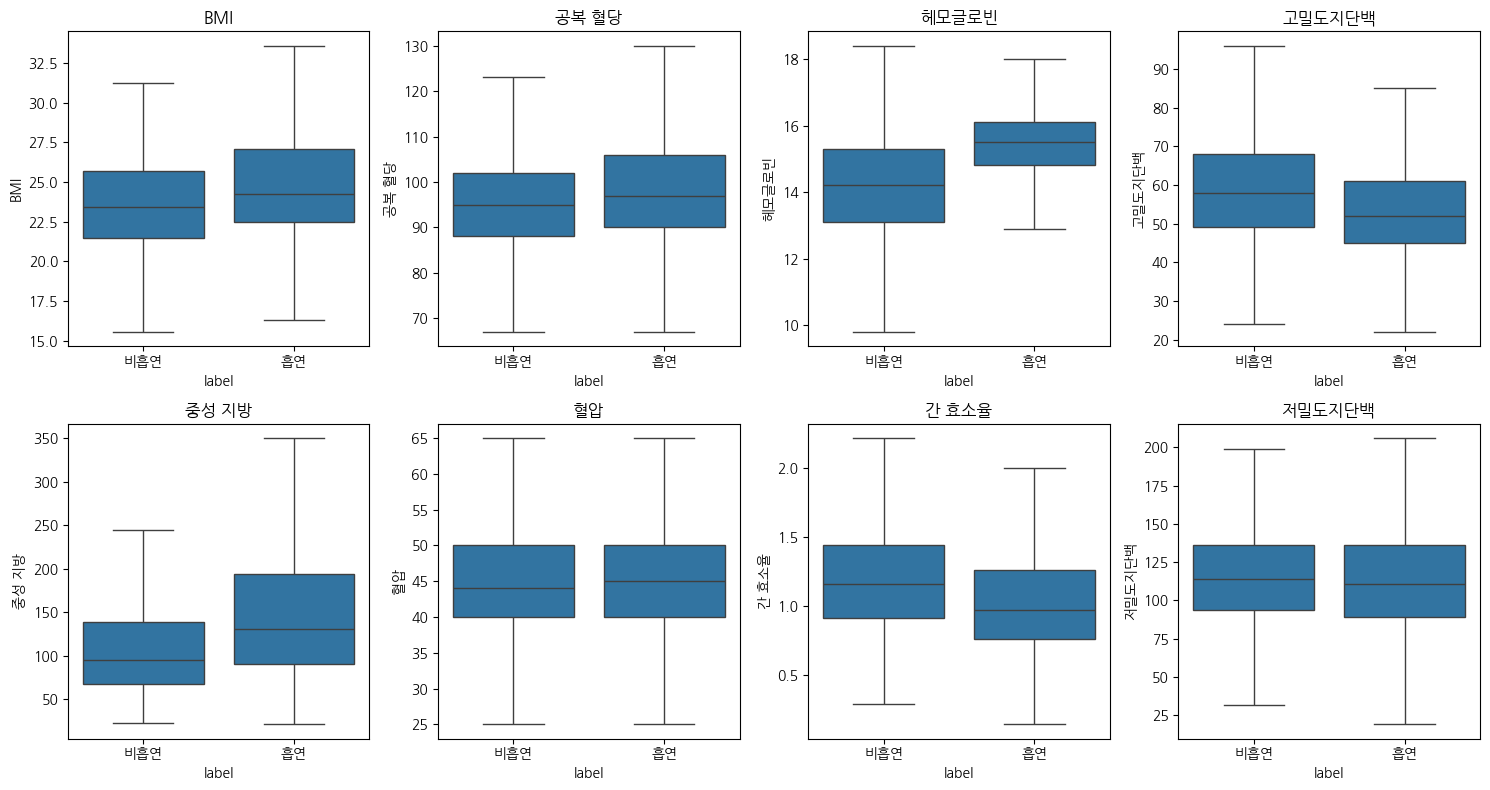

In [ ]:
# Boxplot 차트

cols = ['BMI', '공복 혈당', '헤모글로빈', '고밀도지단백', '중성 지방', '혈압', '간 효소율', '저밀도지단백']

fig, axes = plt.subplots(2, 4, figsize=(15, 8))   # 도화지 비율을 설정

for ax, col in zip(axes.flatten(), cols):

    # Seaborn(sns)을 이용해 박스플롯 그리기
    # x축은 흡연 여부('label'), y축은 현재 반복 중인 건강 지표(col)
    sns.boxplot(x='label', y=col, data=health_data, ax=ax, showfliers=False) # 극단치 표시 off
    ax.set_title(col)

    # 💡 경고 메시지(UserWarning) 처리
    ax.set_xticks([0, 1])                # x축 라벨 변경을 위해, 눈금의 위치를 0과 1로 고정
    ax.set_xticklabels(['비흡연', '흡연'])  # 고정된 눈금 위치(0, 1)에 각각 '비흡연'과 '흡연'

    # ── 그룹별 중앙값 / IQR / 이상치 확인 ──
    print(f"[{col}]")
    for label, name in [(0, '비흡연'), (1, '흡연')]:
        sub = health_data.loc[health_data['label'] == label, col].dropna()

        q1, median, q3 = sub.quantile([0.25, 0.5, 0.75])
        iqr = q3 - q1
        lower_fence = q1 - 1.5 * iqr
        upper_fence = q3 + 1.5 * iqr
        outliers = sub[(sub < lower_fence) | (sub > upper_fence)]

        print(f"{name:>4} | 중앙값: {median:.2f}, IQR: {q1:.2f} ~ {q3:.2f} (IQR폭={iqr:.2f})"
              f", 이상치 - 범위: <{lower_fence:.2f} or >{upper_fence:.2f}"
              f" ({len(outliers)}개 / {len(outliers)/len(sub)*100:.1f}%)"
              )
    print()

plt.tight_layout()
plt.show()


In [ ]:
# 📌 흡연 여부에 따른 지표별 변화(영향) - 평균, 차이, 변화율(%) 계산
for col in ['BMI', '공복 혈당', '헤모글로빈', '중성 지방', '간 효소율', '고밀도지단백', '저밀도지단백', '혈압']:
    smoker_mean = health_data[health_data['label'] == 1][col].mean()
    nonsmoker_mean = health_data[health_data['label'] == 0][col].mean()
    diff = smoker_mean - nonsmoker_mean
    rate = (diff / nonsmoker_mean) * 100

    print(f"[{col}]")
    print(f"흡연군 평균: {smoker_mean:.2f} | 비흡연군 평균: {nonsmoker_mean:.2f}")
    print(f"평균 차이: {diff:+.2f} | 변화율(%): {rate:+.1f}%\n")

[BMI]
흡연군 평균: 24.73 | 비흡연군 평균: 23.81
평균 차이: +0.92 | 변화율(%): +3.9%

[공복 혈당]
흡연군 평균: 102.35 | 비흡연군 평균: 97.50
평균 차이: +4.85 | 변화율(%): +5.0%

[헤모글로빈]
흡연군 평균: 15.45 | 비흡연군 평균: 14.16
평균 차이: +1.29 | 변화율(%): +9.1%

[중성 지방]
흡연군 평균: 150.79 | 비흡연군 평균: 113.22
평균 차이: +37.57 | 변화율(%): +33.2%

[간 효소율]
흡연군 평균: 1.04 | 비흡연군 평균: 1.21
평균 차이: -0.16 | 변화율(%): -13.7%

[고밀도지단백]
흡연군 평균: 53.90 | 비흡연군 평균: 59.36
평균 차이: -5.45 | 변화율(%): -9.2%

[저밀도지단백]
흡연군 평균: 113.06 | 비흡연군 평균: 115.67
평균 차이: -2.61 | 변화율(%): -2.3%

[혈압]
흡연군 평균: 45.78 | 비흡연군 평균: 45.42
평균 차이: +0.36 | 변화율(%): +0.8%



####💡 Boxplot 챠트 해석


> **📌 헤모글로빈 > 중성지방 > 간효소율, 고밀도지단백(HDL), 공복혈당 > BMI, 저밀도지단백(LDL), 혈압 (사실상 무의미)**


| 변수 | 흡연군 평균 | 비흡연군 평균 | 평균 차이 | 변화율(%) | 해석 |
|---|---|---|---|---|---|
| 헤모글로빈 | 15.45 | 14.16 | **+1.29** | **+9.1%** | 가장 큰 변화율, 만성 저산소 보상반응과 일치 |
| 중성지방 | 150.79 | 113.22 | **+37.57** | **+33.2%** | 변화율 가장 큼, 지질대사 이상 |
| 고밀도지단백(HDL) | 53.91 | 59.35 | -5.44 | -9.2% | "좋은 콜레스테롤" 감소, 잘 알려진 패턴 |
| 공복 혈당 | 102.35 | 97.50 | +4.85 | +5.0% | 흡연군이 뚜렷하게 더 높음 (인슐린 저항성 증가 패턴과 일치) |
| BMI | 24.73 | 23.81 | +0.92 | +3.9% | 변화율(3.9%)이 작으며, 두 그룹 간 실질적인 차이는 미미함 |
| 저밀도지단백(LDL) | 113.06 | 115.67 | -2.61 | -2.3% | 변화율 작음, 실질적 차이는 미미 |
| 간 효소율 | 1.04 | 1.21 | -0.16 | -13.7% | 방향이 예상과 반대 (흡연군이 더 낮음) |
| 혈압 | 45.78 | 45.78 | +0.36 | +0.8% | 변화율 거의 0에 가까움, 차이 없다고 봐도 무방 |


```
# 변화율(%) = 차이 / 비흡연군 평균 × 100
```


<br>

#### ⭕ 흡연 여부와 연관성 있는 지표

1. **헤모글로빈**
- 흡연군 중앙값(≈15.44)이 비흡연군(≈14.2)보다 뚜렷하게 높고(d=0.91), 두 박스가 거의 겹치지 않습니다.
- 흡연이 만성적으로 체내 산소 운반 효율을 떨어뜨려서, 몸이 이를 보상하려고 적혈구(헤모글로빈)를 더 많이 만들어내는 생리적 반응으로 잘 알려진 패턴과 일치합니다.

2. **고밀도지단백(HDL)**
- 중앙값 : 흡연군이 비흡연군보다 아래에 있고, 박스가 전반적으로 낮게 형성
- 평균값 : 흡연군(53.91)이 비흡연군(59.35)보다 낮습니다.
- 흡연이 "좋은 콜레스테롤"로 불리는 HDL을 낮춘다는, 심혈관 위험 관점에서 잘 알려진 관계가 확인됩니다.

3. **중성지방**
- 가장 눈에 띄는 롱테일(long-tail) 분포 — 오른쪽으로 극단치가 촘촘하게 이어지는 것을 볼 수 있습니다.
- 흡연군 박스가 위로 이동했을 뿐 아니라 박스 폭 자체가 더 넓어져 흡연군 내 변동성도 커진 것을 볼 수 있습니다.
- 평균값 : 흡연군(150.82)이 비흡연군(113.20)보다 높습니다.
- 이상치(위쪽 점들)가 두 그룹 다 많지만 흡연군 쪽 중앙값 자체가 확연히 높아, 지질대사 이상과 흡연의 연관성을 보여주는 대표적 지표입니다.

4. **공복 혈당**
- 중앙값: 흡연군의 중앙값(97.00)이 비흡연군(95.00)보다 높으며, 데이터가 밀집된 박스(IQR) 전체가 비흡연군에 비해 전반적으로 높게 형성되어 있습니다.
- 변동성 및 이상치: 두 그룹 모두 정상 범위를 넘어 혈당이 매우 높은 이상치(위쪽 점들)가 다수 존재하나, 흡연군의 데이터 변동성(IQR 폭)이 상대적으로 더 큽니다.
- 흡연이 인슐린 저항성을 증가시켜 혈당 상승에 영향을 주고 당뇨병 발병 위험을 높인다는 임상적 지식과 데이터의 패턴이 잘 일치합니다.
<br>

#### ❌ 흡연 여부와 연관성 없는 지표

5. **혈압**
- 두 박스가 중앙값, 사분위 범위, 이상치 위치까지 거의 완벽하게 겹칩니다.
- 평균값 : 흡연군(45.78) vs 비흡연군(45.43) - 유의하지 않음
- 시각적으로 봐도 차이가 없다는 게 바로 보이는 케이스입니다.

6. **간 효소율**
- 흡연군이 오히려 약간 낮은 쪽으로 이동 — 처음 예상(흡연+음주로 높을 것)과 반대 방향
- 평균값 : 흡연군(1.04) vs 비흡연군(1.21) 통계적으로는 유의하지만,  
  방향이 직관과 달라서 이 데이터셋만으로 "흡연이 간 수치를 낮춘다"고 해석하기보다는 다른 교란요인(ex: 음주 여부 데이터 없음, 나이 분포 차이 등)을 의심해봐야 하는 케이스입니다.

7. **BMI (체질량지수)**
- 두 박스가 중앙값, 사분위 범위(IQR) 위치까지 매우 넓게 겹칩니다.
- 중앙값: 흡연군(24.22) vs 비흡연군(23.44)으로 수치상 아주 약간의 차이만 존재합니다.
-시각적으로 봐도 두 그룹 간의 뚜렷한 분포 차이가 없다는 게 바로 보이는 케이스입니다.

8. **저밀도지단백**
- 중앙값 차이가 -3.00으로 아주 작고, IQR 범위도 거의 겹칩니다.(Q3는 136으로 동일).
- 시각적으로 봐도 가장 차이가 안 보이는것을 알 수 있습니다.
- 혈압과 함께 이 6개 변수 중 흡연 여부에 따른 실질적 차이가 가장 미미한 항목으로 보입니다.

<br>

### **📈 histogram**

>  **분포 모양 자체, 정규성 확인**

저밀도지단백 400 초과 5건 제거 (남은 행: 6995)


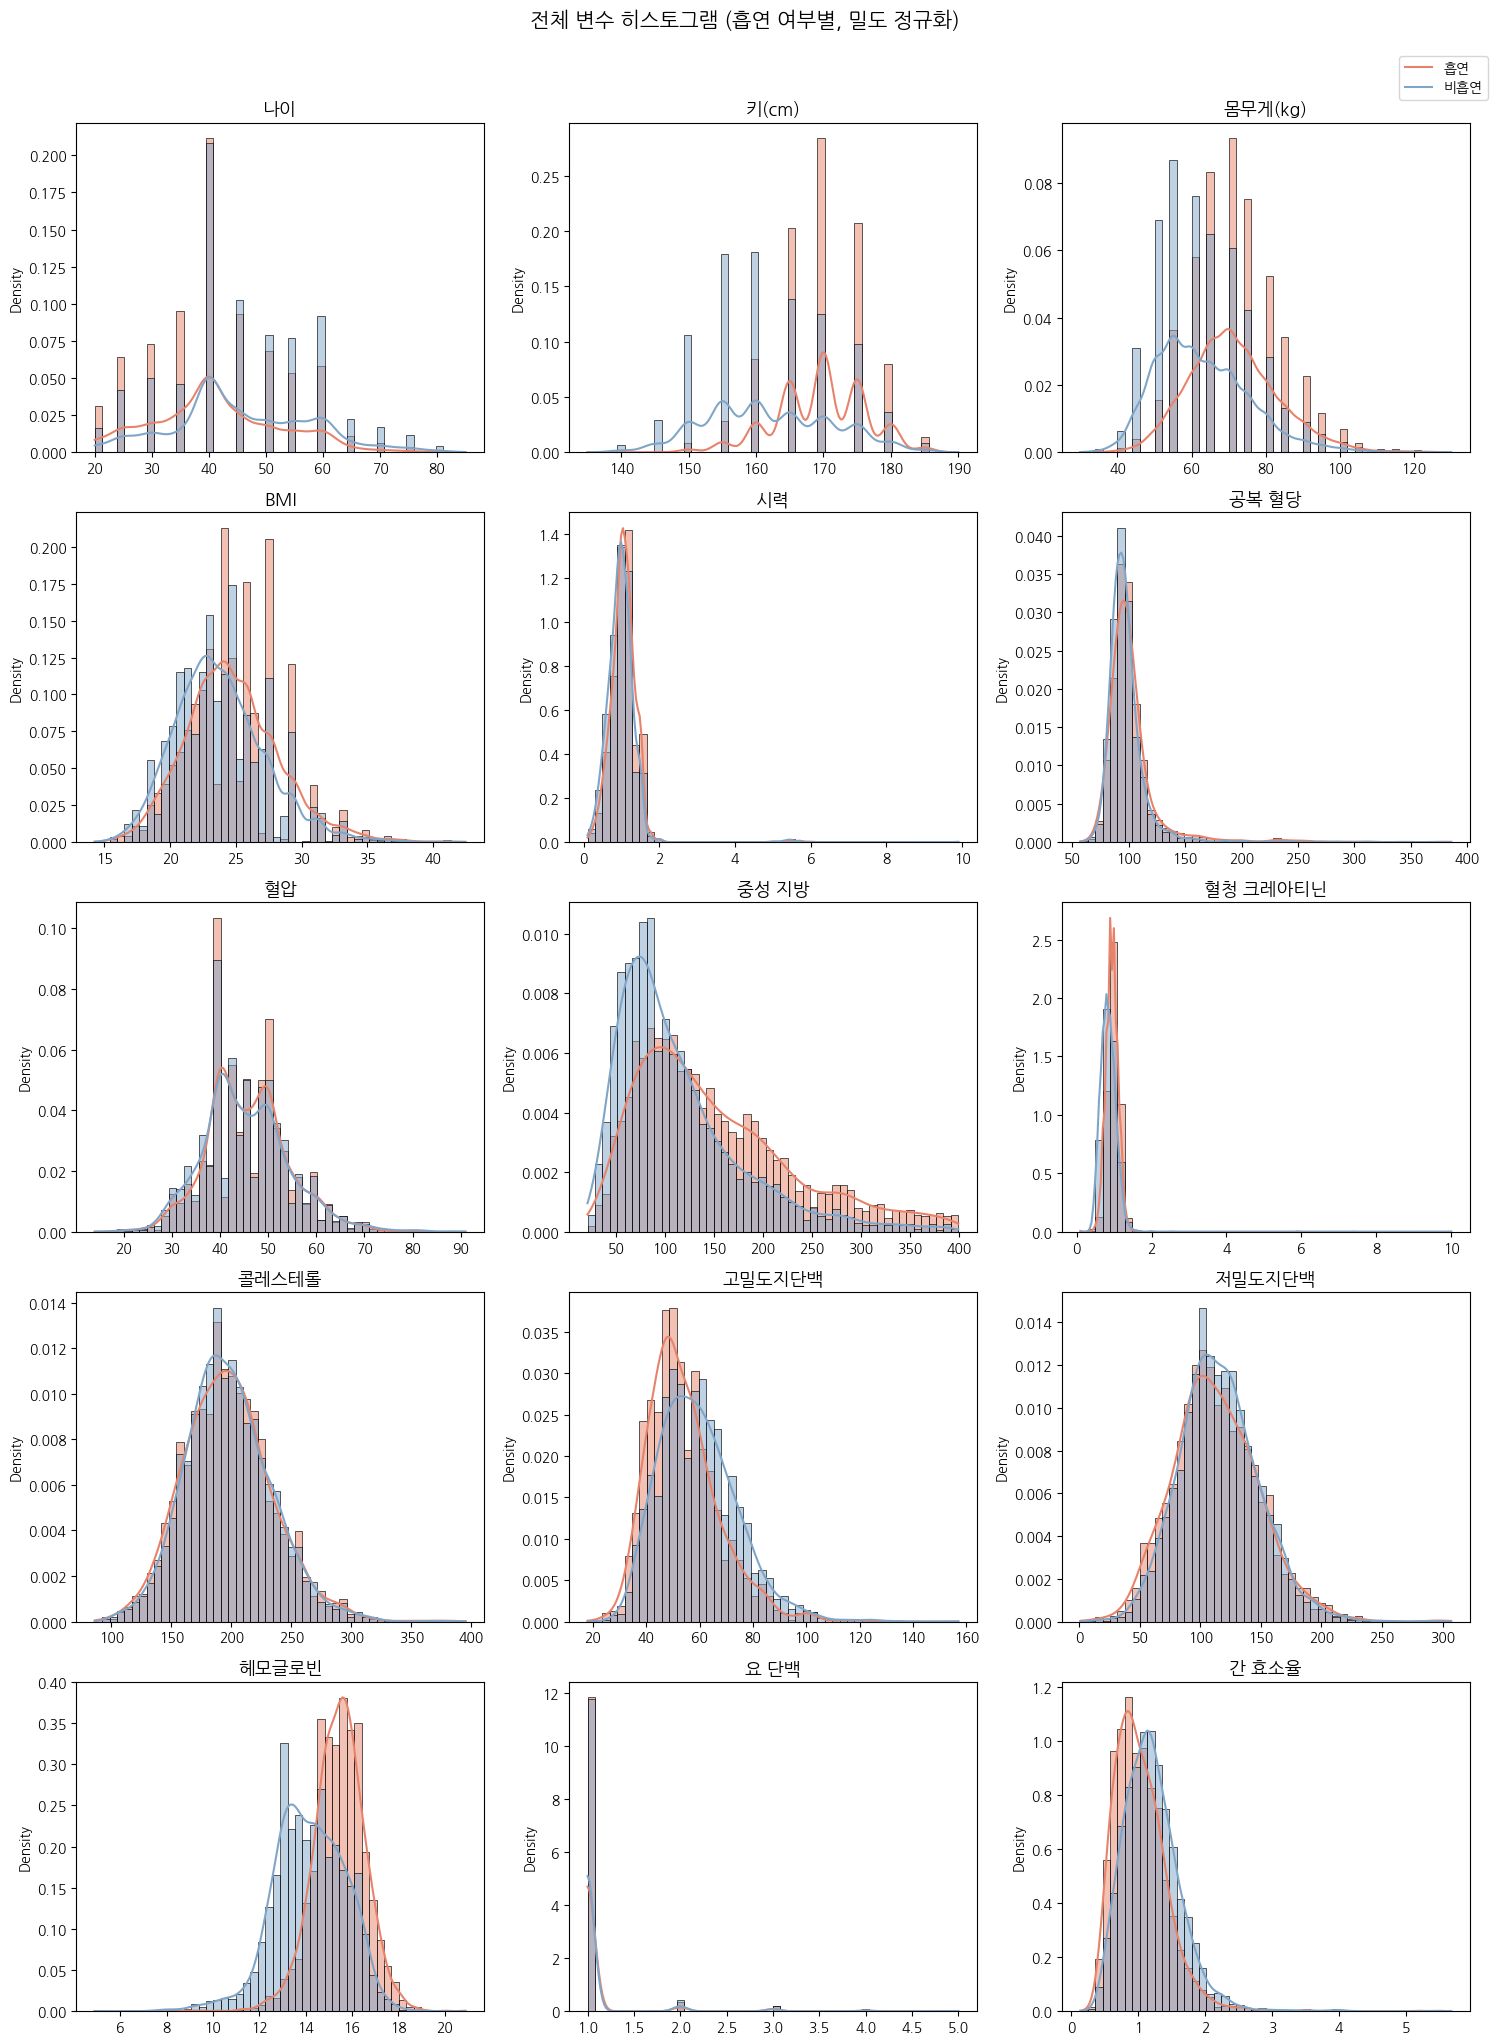

In [ ]:
# 전체 지표와 흡연여부 histogram 챠트
import math

# 1. 이상치 제거 : 저밀도지단백 이상치(400 초과) 제거
before = len(health_data)
health_data = health_data[health_data['저밀도지단백'] <= 400].copy()
print(f"저밀도지단백 400 초과 {before - len(health_data)}건 제거 (남은 행: {len(health_data)})")

# 2. 전체 변수 추출 (ID 및 문자열 제외)
# select_dtypes로 숫자형 변수만 고른 뒤, 'ID' 컬럼이 있다면 삭제하여 리스트로 만들기
cols = health_data.select_dtypes(include=['number']).columns.drop('ID', errors='ignore').tolist()
cols = [col for col in cols if col not in ['label', '충치']]

# 3. 그래프 행(Row) 개수 자동 계산
n_cols = len(cols)
n_rows = math.ceil(n_cols / 3)  # 1줄에 3개씩 그릴 때 필요한 전체 줄(행) 수를 계산

# 4. 전체 지표와 흡연 여부(label)별 히스토그램 (겹쳐서 비교, 밀도로 정규화)
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows)) # 세로 길이를 n_rows에 맞춰 동적으로 늘림

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(
        data=health_data, x=col, hue='label', bins=50, kde=True,
        palette={0: '#7FA6C9', 1: '#E8836B'}, alpha=0.5, ax=ax,
        stat='density', common_norm=False, legend=False
    )
    ax.set_title(col, fontsize=13)
    ax.set_xlabel('')

# 빈칸으로 남는 그래프 영역 숨김 처리
for i in range(n_cols, len(axes.flatten())):
    axes.flatten()[i].set_visible(False)

fig.suptitle('전체 변수 히스토그램 (흡연 여부별, 밀도 정규화)', fontsize=15, y=1.02)
fig.legend(labels=['흡연', '비흡연'], loc='upper right', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

####💡 histogram 챠트 해석

1. **헤모글로빈** - 두 그룹의 봉우리가 뚜렷하게 분리되는 것을 볼 수 있습니다.(비흡연 파랑 : 13 / 흡연 주황 : 15 ~ 16)  
  : 전형적으로 성별 혼재 신호 (남녀 헤모글로빈/체형 기준치가 다르기 때문)
  다만 이 분리는 흡연의 생리적 효과(만성 저산소 상태에 대한 적혈구 보상 증가)만으로 보기 어렵다. 헤모글로빈은 <u>대표적인 성별 차이 지표</u>이며, 대상군 중 흡연율이 성별에 따라 크게 다를 가능성이 있다는 점을 고려하면, 관찰된 분리의 상당 부분이 성별 혼재(confounding) 신호일 수 있다. 성별 컬럼이 없어 직접 확인은 어려웠습니다.

2. **고밀도지단백** - 완만한 정규분포, 흡연군 좌측 이동
- 흡연군 봉우리가 비흡연군보다 왼쪽(낮은 값)으로 이동해 있으며, 데이터가 평균 근처에 더 좁게 몰려있는(뾰족한) 형태를 보입니다
  <font color="blue">"좋은 콜레스테롤"이 흡연군에서 감소한다</font>는, 잘 알려진 패턴과 일치합니다.

3. **중성지방, 간 효소율**: 오른쪽으로 꼬리가 긴 전형적인 우편향 분포
- Boxplot에서 확인됐던 다수의 이상치가 바로 이 꼬리 구간에 해당합니다.
  - 중성지방: 흡연군 분포 전체가 고수치 방향으로 이동하고, 꼬리도 더 두껍습니다.  
  변수 중 흡연군-비흡연군 간 변화율(%)이 가장 큰 지표이기도 합니다.(+33.2%)
  - 간 효소율: 흡연군이 오히려 낮은 값 쪽에 살짝 더 몰려 있습니다.  
  "흡연+음주 습관으로 간 효소가 높을 것"이라는 상식적 가설과 반대 방향으로, 실제 데이터 확인의 중요성을 보여주는 사례입니다.

4. **공복 혈당**
- 정규분포보다 모양보다는 중심에서 오른쪽으로 꼬리가 길게 늘어지는 '우측 편향' 형태를 보이고 있습니다. 이는 평균적인 혈당 수치에 사람들이 많이 몰려 있고, 일부 혈당이 매우 높은 사람들이 존재하기 때문입니다.

5. **BMI (체질량지수)**
- 두 그룹 모두 대략 23~25 부근에서 정점을 찍는 정규분포(종 모양)와 유사한 형태를 띠고 있습니다.
- 그룹 간 차이: 파란색(비흡연자)과 빨간색(흡연자) 분포가 거의 완벽하게 겹쳐져 있는 것을 볼 수 있습니다.

6. **혈압** - 다봉(multimodal) 패턴, 이산적 기록 가능성
- 정규분포가 아니라 30, 40, 50 등 특정 정수 부근에서 막대가 뾰족하게 튀는 다봉 형태를 보이고 있습니다.
- 값을 찍어보니 정수 단위로 특정 값(30, 40, 50…)에 응답이 몰려 있어, 연속 측정값이라기보다 이산적으로 기록되었거나 반올림된 값일 가능성이 있으므로, 다봉 패턴의 원인에 대한 추가 확인이 필요해 보입니다.
- 흡연군-비흡연군 분포는 거의 겹치며, 통계적으로도 유의한 차이가 없습니다.

7. **저밀도지단백**
- 수정 전 : **데이터 오류로 보이는 극단치 발견**(x축이 ~ 1400까지 늘어나 있음)
  - 극단치 : 1340, 1120, 1070, 910 같은 값이 섞여 있습니다.  
  - LDL 콜레스테롤은 아무리 높아도 보통 300 ~ 400을 넘기 어렵기 때문에 입력 오류(단위 실수 등)일 가능성이 높습니다. 분석 전에 이런 극단치는 제거하거나 별도 확인이 필요합니다.
- 극단치 제거 후 : 정상적인 종 모양(정규분포에 가까운) 분포
  - 흡연군-비흡연군 분포는 거의 완전히 겹치며, 와 정확히 일치합니다.

##### ✅ 종합 해석

1. **가장 신뢰할 수 있는 변수**
- 헤모글로빈, 중성지방, 고밀도 지단백(HDL), 공복 혈당 — 변수 모두 boxplot·histogram·scatterplot에서 일관되게 그룹 분리가 확인되었습니다.

2. **차이가 없다고 결론 내릴 수 있는 변수**
- 혈압, 저밀도지단백(LDL) — 시각화와 통계 검정 모두 일치된 결론을 보였습니다.

3. **방향이 예상과 달랐던 변수**
- 간 효소율 — 상식적 가설(흡연=간효소 상승)과 반대로 나타나, 가정에 의존하지 않고 데이터를 직접 확인하는 절차의 필요성을 보여줍니다.

4. **데이터 품질 이슈**
- 저밀도지단백(LDL) 변수에서 발견된 극단치는 분석 결과를 왜곡할 수 있는 수준이었습니다.  
원본 데이터를 그대로 사용하기 전 이상치 점검이 필수적임을 확인할 수있는 부분이었습니다.



<br>

### **📈 scatterplot**

>  변수 간 상관관계 (예: 키-몸무게, 중성지방-HDL)
- 범위: -1 ~ +1 사이의 값만 가집니다
- 해석 (r)  
  0.0 ~ 0.2(거의 없음), 0.2 ~ 0.4(약한 상관), 0.4 ~ 0.6(중간 상관), 0.6 ~ 0.8(강한 상관), 0.8 ~ 1.0(매우 강한 상관)

- 피어슨 상관계수 : 두 연속형 변수가 얼마나 강하게, 어느 방향으로 선형적인 관계를 갖는지를 하나의 숫자로 나타낸 값
<br>

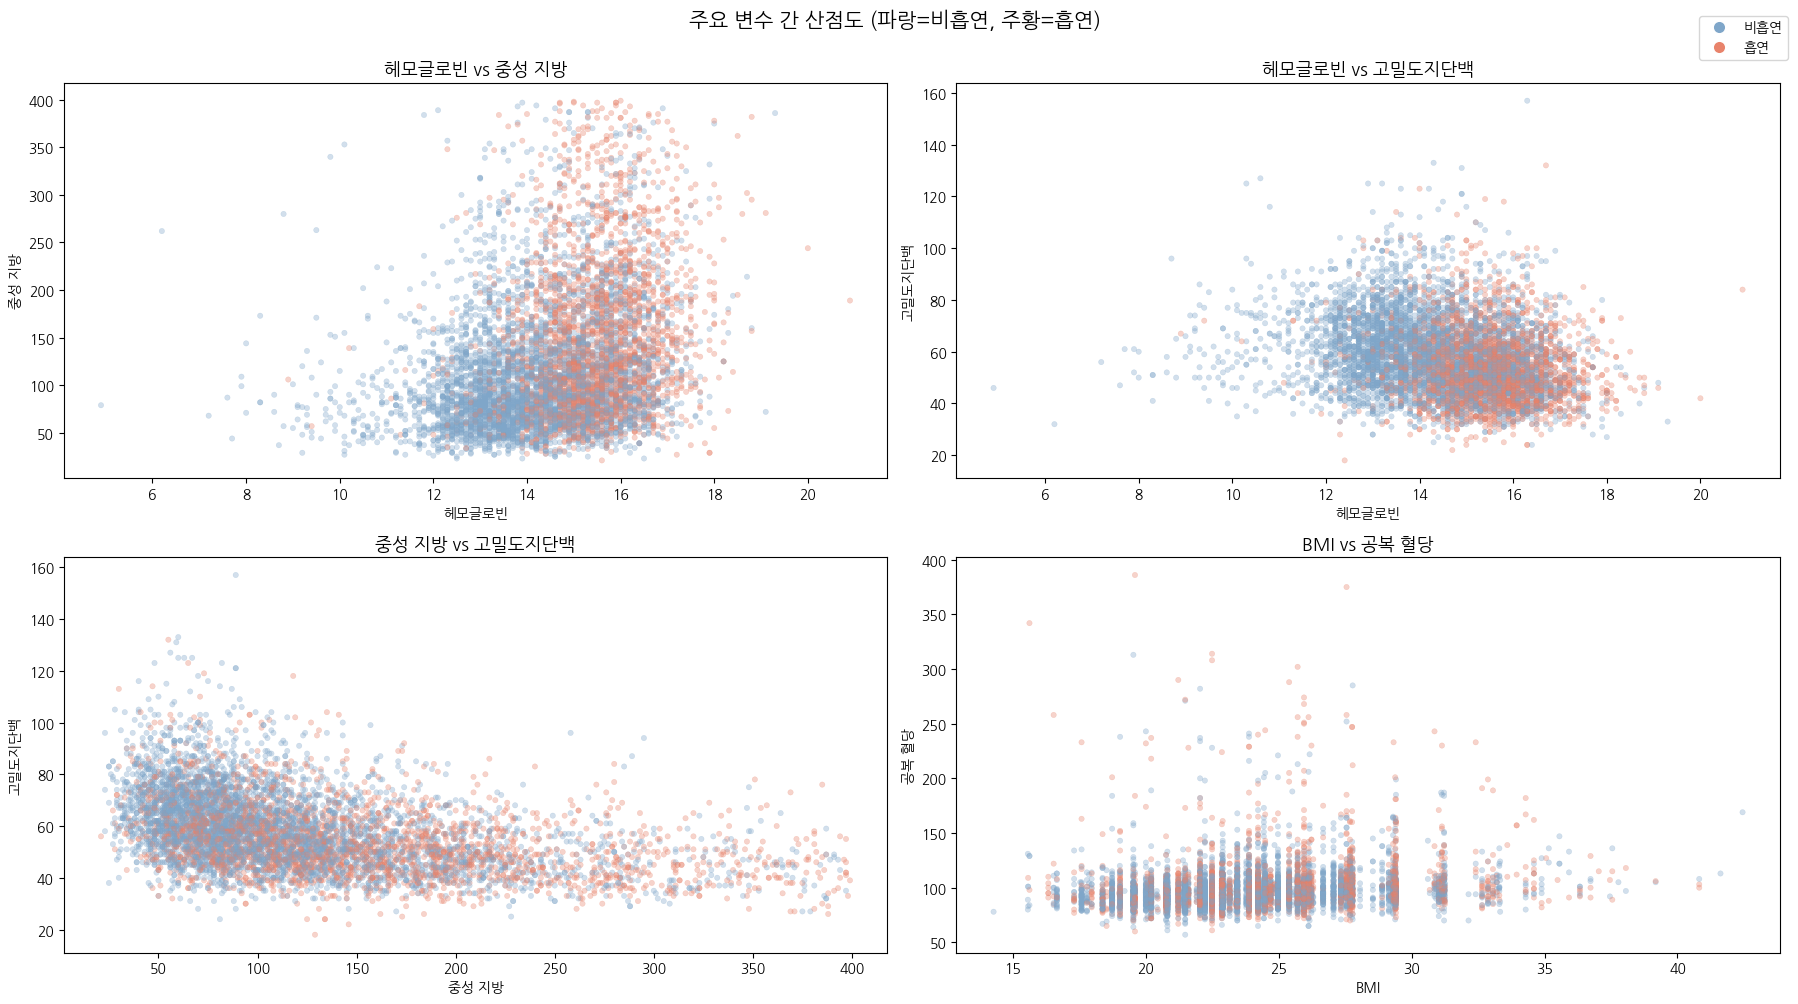

헤모글로빈 vs 중성 지방: r = 0.278
헤모글로빈 vs 고밀도지단백: r = -0.252
중성 지방 vs 고밀도지단백: r = -0.427
BMI vs 공복 혈당: r = 0.153


In [ ]:
# scatterplot 챠트

pairs = [
    ('헤모글로빈', '중성 지방'),
    ('헤모글로빈', '고밀도지단백'),
    ('중성 지방', '고밀도지단백'),
    ('BMI', '공복 혈당')
]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
palette = {0: '#7FA6C9', 1: '#E8836B'}

for ax, (x, y) in zip(axes.flatten(), pairs):
    sns.scatterplot(data=health_data, x=x, y=y, hue='label', palette=palette, alpha=0.35, s=15, ax=ax, edgecolor=None, legend=False)
    ax.set_title(f'{x} vs {y}', fontsize=13)

fig.suptitle('주요 변수 간 산점도 (파랑=비흡연, 주황=흡연)', fontsize=15, y=1.0)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=9)
           for c in palette.values()]
fig.legend(handles, ['비흡연', '흡연'], loc='upper right', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
# plt.savefig('scatter_pairs.png', dpi=130, bbox_inches='tight')
plt.show()

# 상관계수 함께 확인
for x, y in pairs:
    r = health_data[x].corr(health_data[y]) # 피어슨 상관계수
    print(f"{x} vs {y}: r = {r:.3f}")


####💡 Scatterplot 챠트 해석

1. **헤모글로빈 vs 중성지방** (r = 0.276)
- 비흡연군(파랑) : 왼쪽 아래 저밀도 구역(헤모글로빈 12 ~ 15, 중성지방 50 ~ 150)에 뭉쳐 있고,  
흡연군(주황) : 오른쪽 위(헤모글로빈 14 ~ 17, 중성지방 100 ~ 250 이상)로 대각선을 그리며 이동해 있습니다.
- 평균으로 보면 비흡연 (14.16, 113.2) → 흡연 (15.44, 150.8)로 두 지표 모두 같은 방향으로 함께 이동하고 있습니다.
- 중앙의 겹치는 구간(헤모글로빈 13 ~ 16, 중성지방 80 ~ 200)은 두 그룹이 섞여있어서, 이 두 변수만으로 완벽하게 흡연 여부를 구분하기는 어렵습니다
- 개별 변수 하나로는 절대 흡연자를 못 가려내는 게 당연하지만,  방향이나 밀집도의 경향성 자체는 명확해 보입니다.


2. **헤모글로빈 vs 고밀도지단백(HDL)** (r = -0.252)
- 비흡연(파랑) : 왼쪽 위(헤모글로빈↓, HDL↑) 영역에 더 많고,  
흡연(주황) : 오른쪽 아래(헤모글로빈↑, HDL↓)로 이동해 있습니다.
- 다만 겹치는 정도가 헤모글로빈-중성지방 조합보다 큽니다.
- 실제로 두 그룹의 뭉치는 정도(응집력)가 눈으로도 덜 뚜렷합니다.

3. **중성지방 vs 고밀도지단백(HDL)** (r = -0.427)
- 중성지방이 낮을 때 고밀도지단백(HDL)이 넓게 퍼져있다가,  
중성지방이 올라갈수록 고밀도지단백(HDL)이 낮은 쪽으로 수렴하는 깔때기 모양을 보이고 있습니다.
- 흡연군(주황)이 이 곡선의 "나쁜 쪽"(중성지방↑, HDL↓)에 살짝 더 많이 위치합니다.

4. **BMI vs 공복 혈당** (r = 0.153)
- 점들이 뚜렷한 대각선이나 선형(직선)을 그리지 않고,  넓게 퍼져 있는 형태를 띄고 있습니다.
- 상관계수(r) = 0.153: 0에 꽤 가까운 양수입니다. 이는 "BMI가 높아질수록 공복 혈당도 약간 높아지는 경향이 있긴 하지만, 그 관계가 매우 약하다"는 것을 의미합니다.

##### ✅  **종합**
- 그래프 모두에서 흡연군(주황)이 무작위로 섞여있지 않고 특정 영역(체격이 크고, 지질 수치가 나쁜 쪽)에 편중되는 경향이 보입니다.
- 성별 컬럼이 없다는 한계 때문에 이게 "흡연의 순수 효과"인지 "흡연군에 남성이 많아서"인지는 시각화만으로는 확인할 수 없으므로, 성별 데이터를 추가 하거나 키/몸무게 기반으로 성별을 근사 추정해서 재분석을 해보는 것도 고려해볼 만합니다.

---
## 4. 가설 수립하기 (최소 3개)
흡연 여부(label)에 따라 각 건강 지표에 통계적으로 유의미한 차이가 있는지 검증하기 위한 가설을 수립합니다.

각 건강 지표(예: BMI, 혈압, 혈당 등)에 대해 최소 3개 이상의 가설을 작성해 보세요.

**(예시)**
- H₀ (귀무가설): BMI- 흡연자와 비흡연자의 평균 BMI는 같다.
- H₁ (대립가설): BMI- 흡연자와 비흡연자의 평균 BMI는 다르다.

##### **[TODO] 3가지 분석 가설 설정**
- 아래 코드 셀에 흡연자와 비흡연자 간의 건강 지표 차이를 검증하기 위한 3가지 가설을 설정하세요.

#### 💭 **<font color="dimgray">가설 ‼️</font>**

1. **헤모글로빈** <font color="red">높은</font> (상위 25%) 사람의 비율은 흡연군에서 더 높다
2. **중성지방** <font color="red">높은</font> (≥150) 사람의 비율은 흡연군에서 더 높다

3. **고밀도지단백(HDL)** <font color="blue">낮은</font> (<40)  사람의 비율은 흡연군에서 더 높다

4. **BMI** (≥25)와 **공복혈당*(>100)이 <font color="red">높은</font> 사람의 비율은 흡연군에서 더 높다

---
## 5. 단변량 분석
단변량 분석은 각 변수(컬럼)의 특성을 개별적으로 탐색하는 과정입니다. 이를 통해 데이터의 전반적인 이해도를 높이고, 이상치나 결측값 등의 문제점을 파악할 수 있습니다.

#### 단변량 분석 목적:
-   **데이터 품질 확인**: 결측값, 이상치 등의 존재 여부를 파악합니다.
-   **변수 유형 이해**: 각 변수가 숫자형인지 범주형인지 구분하고, 데이터의 특성을 파악합니다.
-   **기초 통계량 확인**: 평균, 중앙값, 표준편차 등 핵심 통계치를 통해 데이터의 중심 경향과 퍼짐 정도를 파악합니다.
-   **분포 시각화**: 히스토그램, 박스 플롯 등을 통해 변수의 분포 형태를 시각적으로 확인합니다.
-   **전처리 필요성 판단**: NaN 값 처리, 가변수(Dummy Variable) 생성 등 추가 전처리 필요성을 결정합니다.
-   **비즈니스 인사이트 도출**: 각 변수가 어떤 의미를 가지며, 어떤 비즈니스적 함의를 갖는지 정리합니다.
-   **추가 분석 아이디어 발굴**: 단변량 분석 결과로부터 더 깊이 탐색할 만한 주제나 관계를 도출합니다.

##### **[TODO] 단변량 분석 수행**

다음 코드 셀에서 `health_data` DataFrame의 각 변수에 대해 단변량 분석을 수행해 보세요.

In [ ]:
# 데이터 구조 및 결측치 확인
health_data.info()
health_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 6995 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   ID        6995 non-null   object  
 1   나이        6995 non-null   int64   
 2   키(cm)     6995 non-null   int64   
 3   몸무게(kg)   6995 non-null   int64   
 4   BMI       6995 non-null   float64 
 5   시력        6995 non-null   float64 
 6   충치        6995 non-null   int64   
 7   공복 혈당     6995 non-null   float64 
 8   혈압        6995 non-null   float64 
 9   중성 지방     6995 non-null   float64 
 10  혈청 크레아티닌  6995 non-null   float64 
 11  콜레스테롤     6995 non-null   int64   
 12  고밀도지단백    6995 non-null   int64   
 13  저밀도지단백    6995 non-null   int64   
 14  헤모글로빈     6995 non-null   float64 
 15  요 단백      6995 non-null   int64   
 16  간 효소율     6995 non-null   float64 
 17  label     6995 non-null   int64   
 18  체중 상태     6995 non-null   category
 19  나이대       6995 non-null   category
dtypes: category(2

,0
ID,0
나이,0
키(cm),0
몸무게(kg),0
BMI,0
시력,0
충치,0
공복 혈당,0
혈압,0
중성 지방,0


In [ ]:
# 기초 통계량 확인
health_data.describe()

,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
count,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000
mean,43.974267,164.779843,65.930665,24.144019,1.015311,0.227448,99.277586,45.541101,127.027672,0.884675,197.294925,57.353681,114.710222,14.631122,1.083917,1.144914,0.367262
std,12.064343,9.172675,12.981594,3.502697,0.426689,0.419214,20.925823,8.743026,72.494803,0.241266,36.309662,14.510806,33.697700,1.540815,0.392185,0.432775,0.482093
min,20.000000,135.000000,30.000000,14.270000,0.100000,0.000000,57.000000,14.000000,21.000000,0.100000,86.000000,18.000000,1.000000,4.900000,1.000000,0.140000,0.000000
25%,35.000000,160.000000,55.000000,21.600000,0.800000,0.000000,89.000000,40.000000,74.000000,0.800000,173.000000,47.000000,92.000000,13.600000,1.000000,0.840000,0.000000
50%,40.000000,165.000000,65.000000,23.880000,1.000000,0.000000,96.000000,45.000000,108.000000,0.900000,195.000000,55.000000,113.000000,14.800000,1.000000,1.100000,0.000000
75%,50.000000,170.000000,75.000000,26.120000,1.200000,0.000000,103.000000,50.000000,160.000000,1.000000,219.000000,66.000000,136.000000,15.700000,1.000000,1.380000,1.000000
max,85.000000,190.000000,130.000000,42.450000,9.900000,1.000000,386.000000,91.000000,399.000000,10.000000,395.000000,157.000000,307.000000,20.900000,5.000000,5.670000,1.000000


In [ ]:
# 이상치(Outliers) 파악
health_data.describe()


,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
count,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000,6995.000000
mean,43.974267,164.779843,65.930665,24.144019,1.015311,0.227448,99.277586,45.541101,127.027672,0.884675,197.294925,57.353681,114.710222,14.631122,1.083917,1.144914,0.367262
std,12.064343,9.172675,12.981594,3.502697,0.426689,0.419214,20.925823,8.743026,72.494803,0.241266,36.309662,14.510806,33.697700,1.540815,0.392185,0.432775,0.482093
min,20.000000,135.000000,30.000000,14.270000,0.100000,0.000000,57.000000,14.000000,21.000000,0.100000,86.000000,18.000000,1.000000,4.900000,1.000000,0.140000,0.000000
25%,35.000000,160.000000,55.000000,21.600000,0.800000,0.000000,89.000000,40.000000,74.000000,0.800000,173.000000,47.000000,92.000000,13.600000,1.000000,0.840000,0.000000
50%,40.000000,165.000000,65.000000,23.880000,1.000000,0.000000,96.000000,45.000000,108.000000,0.900000,195.000000,55.000000,113.000000,14.800000,1.000000,1.100000,0.000000
75%,50.000000,170.000000,75.000000,26.120000,1.200000,0.000000,103.000000,50.000000,160.000000,1.000000,219.000000,66.000000,136.000000,15.700000,1.000000,1.380000,1.000000
max,85.000000,190.000000,130.000000,42.450000,9.900000,1.000000,386.000000,91.000000,399.000000,10.000000,395.000000,157.000000,307.000000,20.900000,5.000000,5.670000,1.000000


#### 🗒️ **<font color="darkgreen">단변량 분석 결과</font>**

##### ⁉️ 대표적 이상치

1. **시력**
- 평균(mean)이 약 1.0이고 75% 백분위수가 1.2인데, 최댓값(max)이 9.9로 나타납니다.
- 이유: 일반적인 시력 검사에서 9.9라는 수치는 나올 수 없는 값입니다. 보통 이런 경우 시력 측정이 불가한 상태(실명 등)를 9.9로 표기했거나, 데이터 입력 과정에서 발생한 오타(오류)일 확률이 매우 높습니다.

2. **공복 혈당**
- 75% 백분위수가 104, 평균이 약 99.2로 대부분 100 내외에 분포하고 있지만, 최댓값(max)이 386입니다.
- 공복 혈당 386은 전체 데이터의 일반적인 분포(대다수가 100 이하)와 비교하면 극단적으로 높은 값(극단치)이므로, 데이터 분석(특히 평균 활용시)에 영향을 줄 수 있는 뚜렷한 통계적 이상치로 볼 수 있습니다. (당뇨병 진단 기준 공복혈당 : 126mg/dL)

3. **몸무게(kg) 및 BMI**
- 몸무게의 최솟값(min)이 30kg, 최댓값(max)이 130kg입니다.
- 불가능한 수치는 아니지만, 성인 기준으로 30kg은 매우 적은 수치이며 130kg 역시 상위 극단에 속합니다. 이로 인해 파생 변수인 BMI 역시 최댓값이 42.45로 고도비만 수준의 극단치가 존재함을 알 수 있습니다.

In [ ]:
# 몸무게가 38kg 이하 | 120kg 이상인 데이터만 필터링하여 확인
health_data[(health_data['몸무게(kg)'] <= 38) | (health_data['몸무게(kg)'] >= 120)]

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label,체중 상태,나이대
80,TRAIN_0080,60,140,35,17.86,1.00,0,112.0,53.0,60.000000,0.8,254,81,161,12.5,1,0.90,0,저체중,60대
731,TRAIN_0731,30,185,120,35.06,1.00,0,127.0,50.0,167.000000,0.7,206,37,136,16.4,1,0.51,1,3단계 비만,30대
1124,TRAIN_1124,45,145,35,16.65,1.00,0,113.0,48.0,123.939548,0.7,270,87,170,13.7,1,0.85,0,저체중,40대
1125,TRAIN_1125,75,135,35,19.20,0.20,0,97.0,43.0,76.000000,0.8,133,42,75,11.9,1,1.55,0,정상,70대
1836,TRAIN_1836,30,175,125,40.82,0.40,0,103.0,55.0,185.000000,1.0,149,52,60,16.0,1,0.52,1,3단계 비만,30대
1982,TRAIN_1982,40,140,35,17.86,0.30,0,87.0,42.0,41.000000,0.6,135,75,52,10.4,1,1.14,0,저체중,40대
2002,TRAIN_2002,40,150,35,15.56,0.90,0,89.0,33.0,35.000000,0.7,198,76,115,13.2,1,1.00,0,저체중,40대
2100,TRAIN_2100,60,140,35,17.86,1.00,0,104.0,48.0,143.000000,0.6,199,40,130,13.6,1,1.65,0,저체중,60대
3153,TRAIN_3153,25,175,120,39.18,1.20,0,105.0,55.0,199.000000,0.8,181,44,97,15.5,1,0.76,0,3단계 비만,20대
3539,TRAIN_3539,40,180,120,37.04,1.00,0,115.0,50.0,107.000000,0.7,197,37,148,15.6,1,0.45,1,3단계 비만,40대


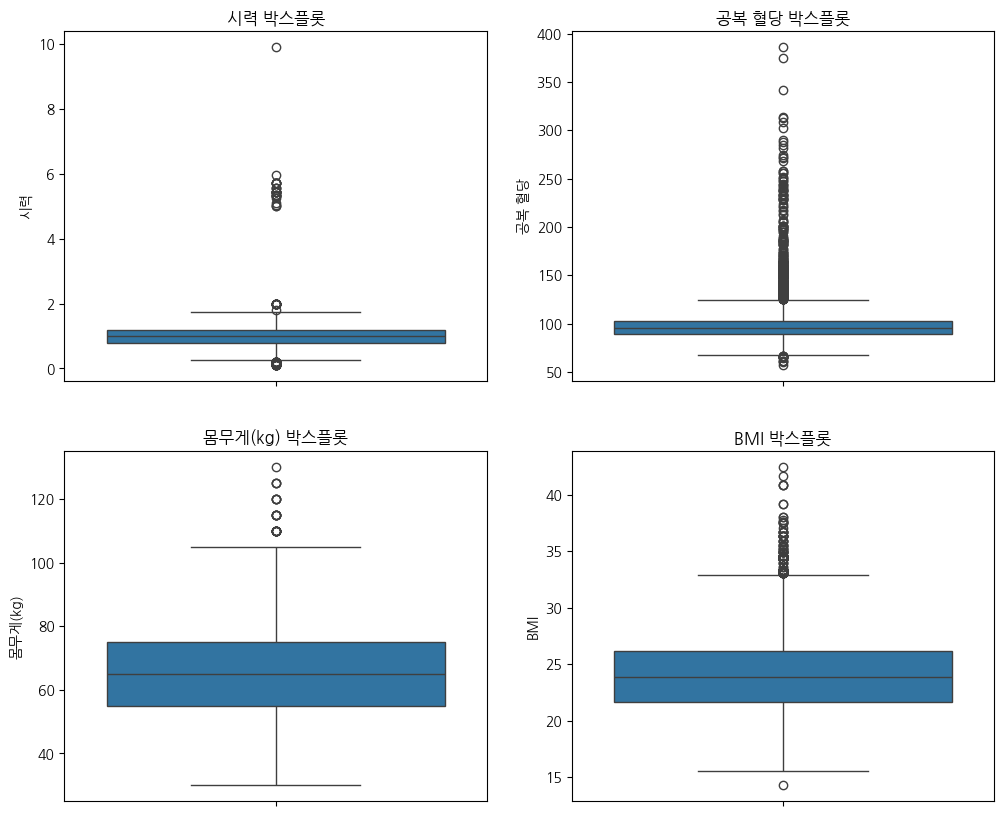

In [ ]:
# 시력과 공복 혈당의 이상치 시각적 확인
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

sns.boxplot(y=health_data['시력'], ax=axes[0]).set_title('시력 박스플롯')
sns.boxplot(y=health_data['공복 혈당'], ax=axes[1]).set_title('공복 혈당 박스플롯')
sns.boxplot(y=health_data['몸무게(kg)'], ax=axes[2]).set_title('몸무게(kg) 박스플롯')
sns.boxplot(y=health_data['BMI'], ax=axes[3]).set_title('BMI 박스플롯')
plt.show()

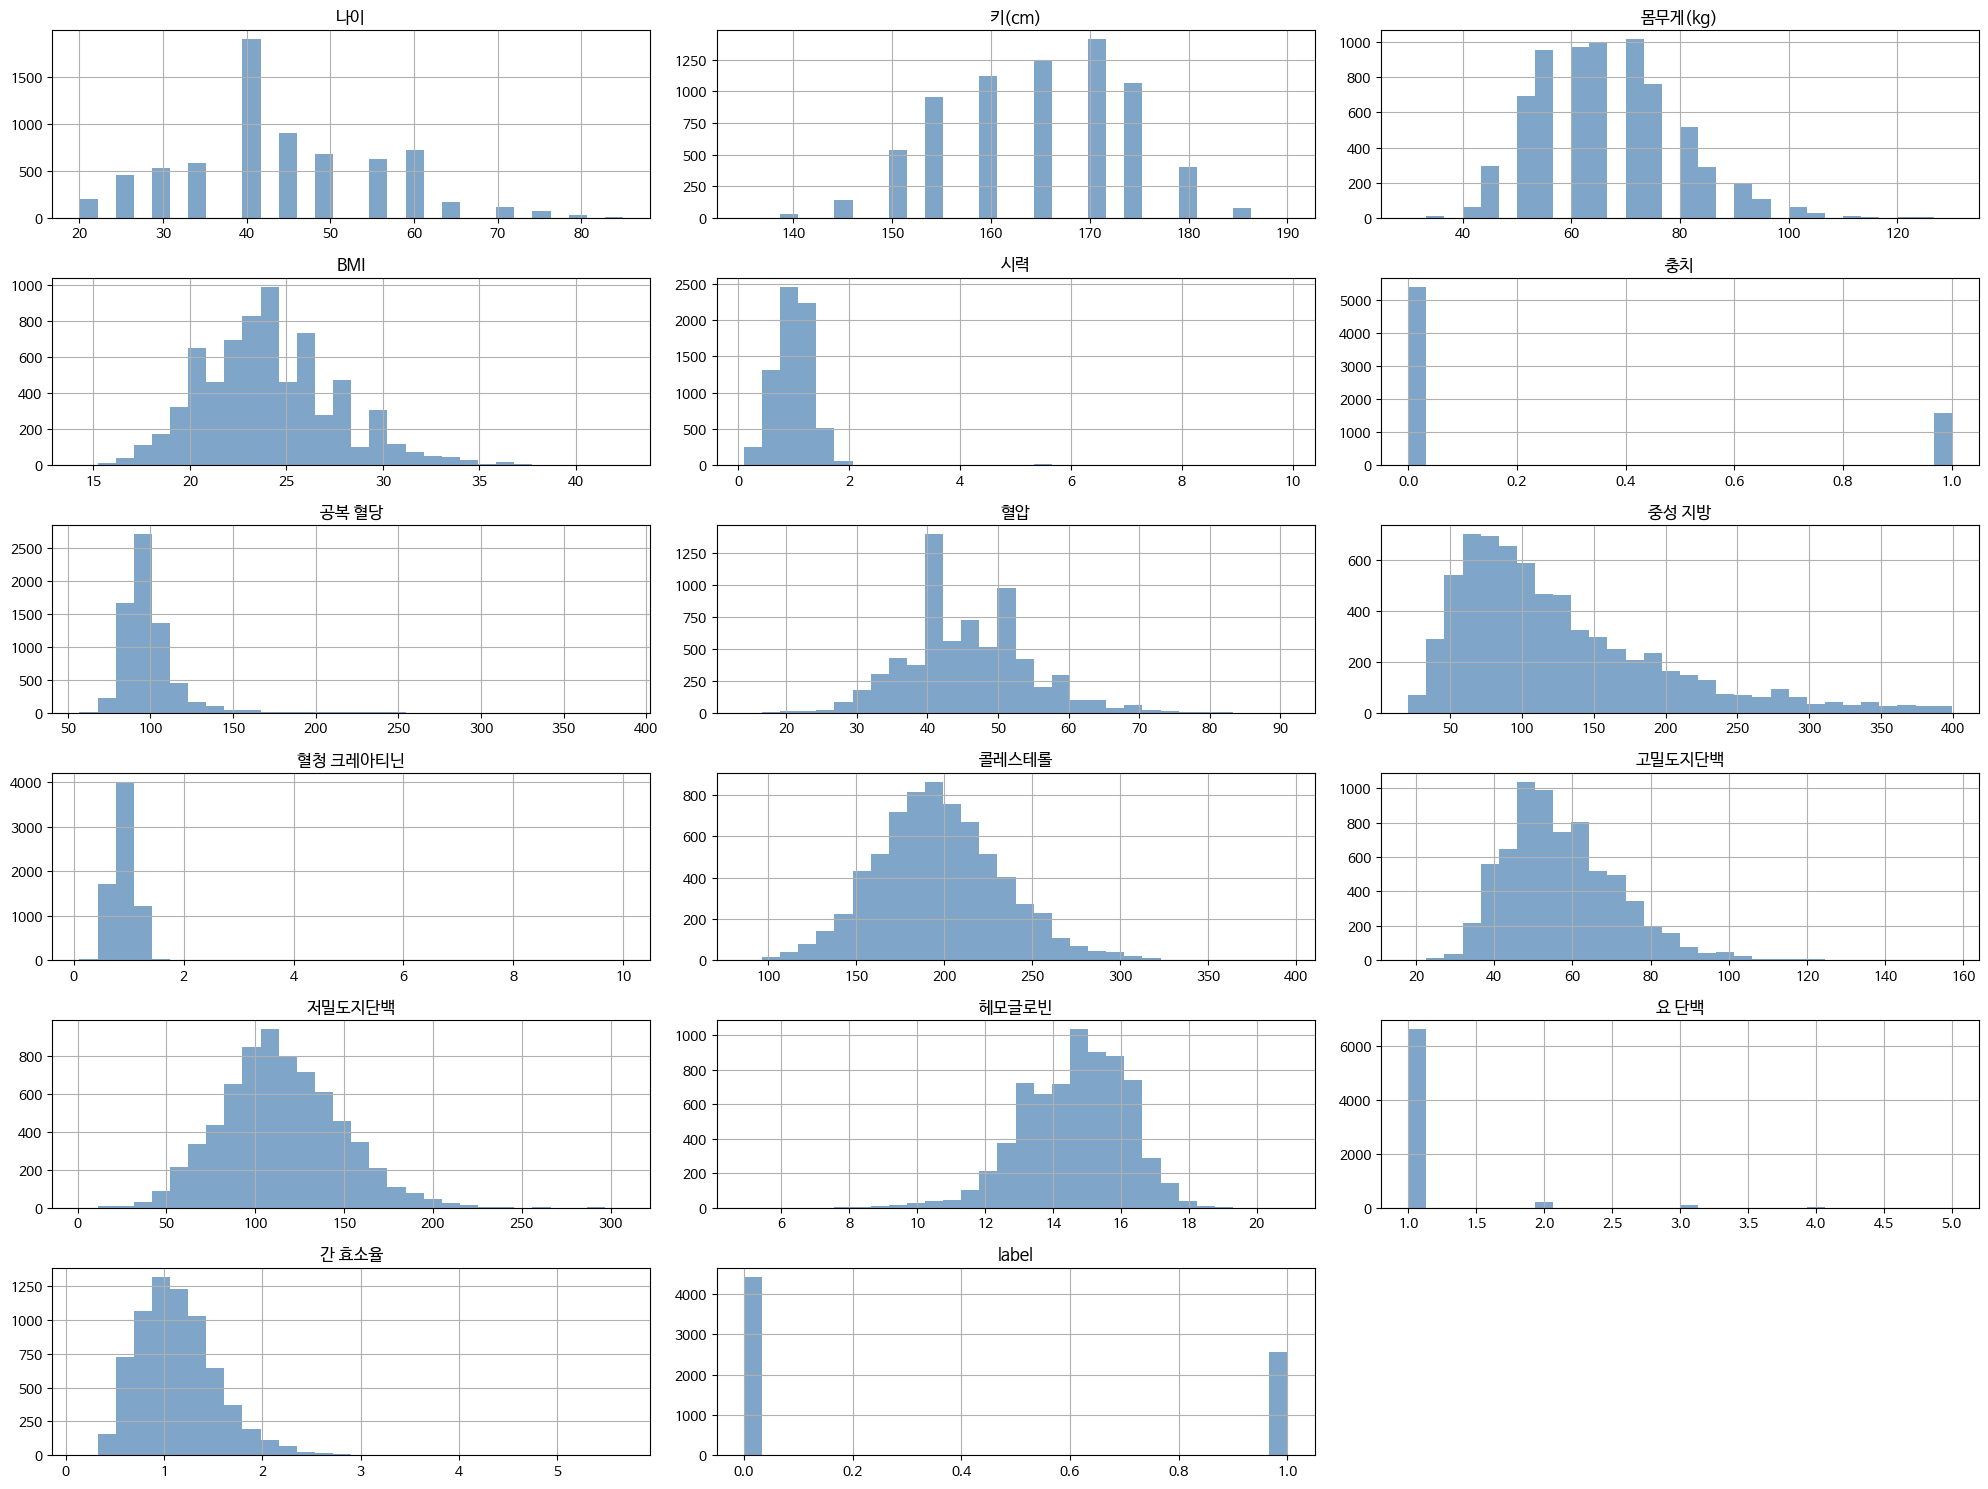

In [ ]:
# 전체 숫자형 변수의 분포를 한눈에 파악
health_data.hist(bins=30, figsize=(20, 15), color='#7FA6C9', layout=(6, 3))
plt.tight_layout()
plt.show()

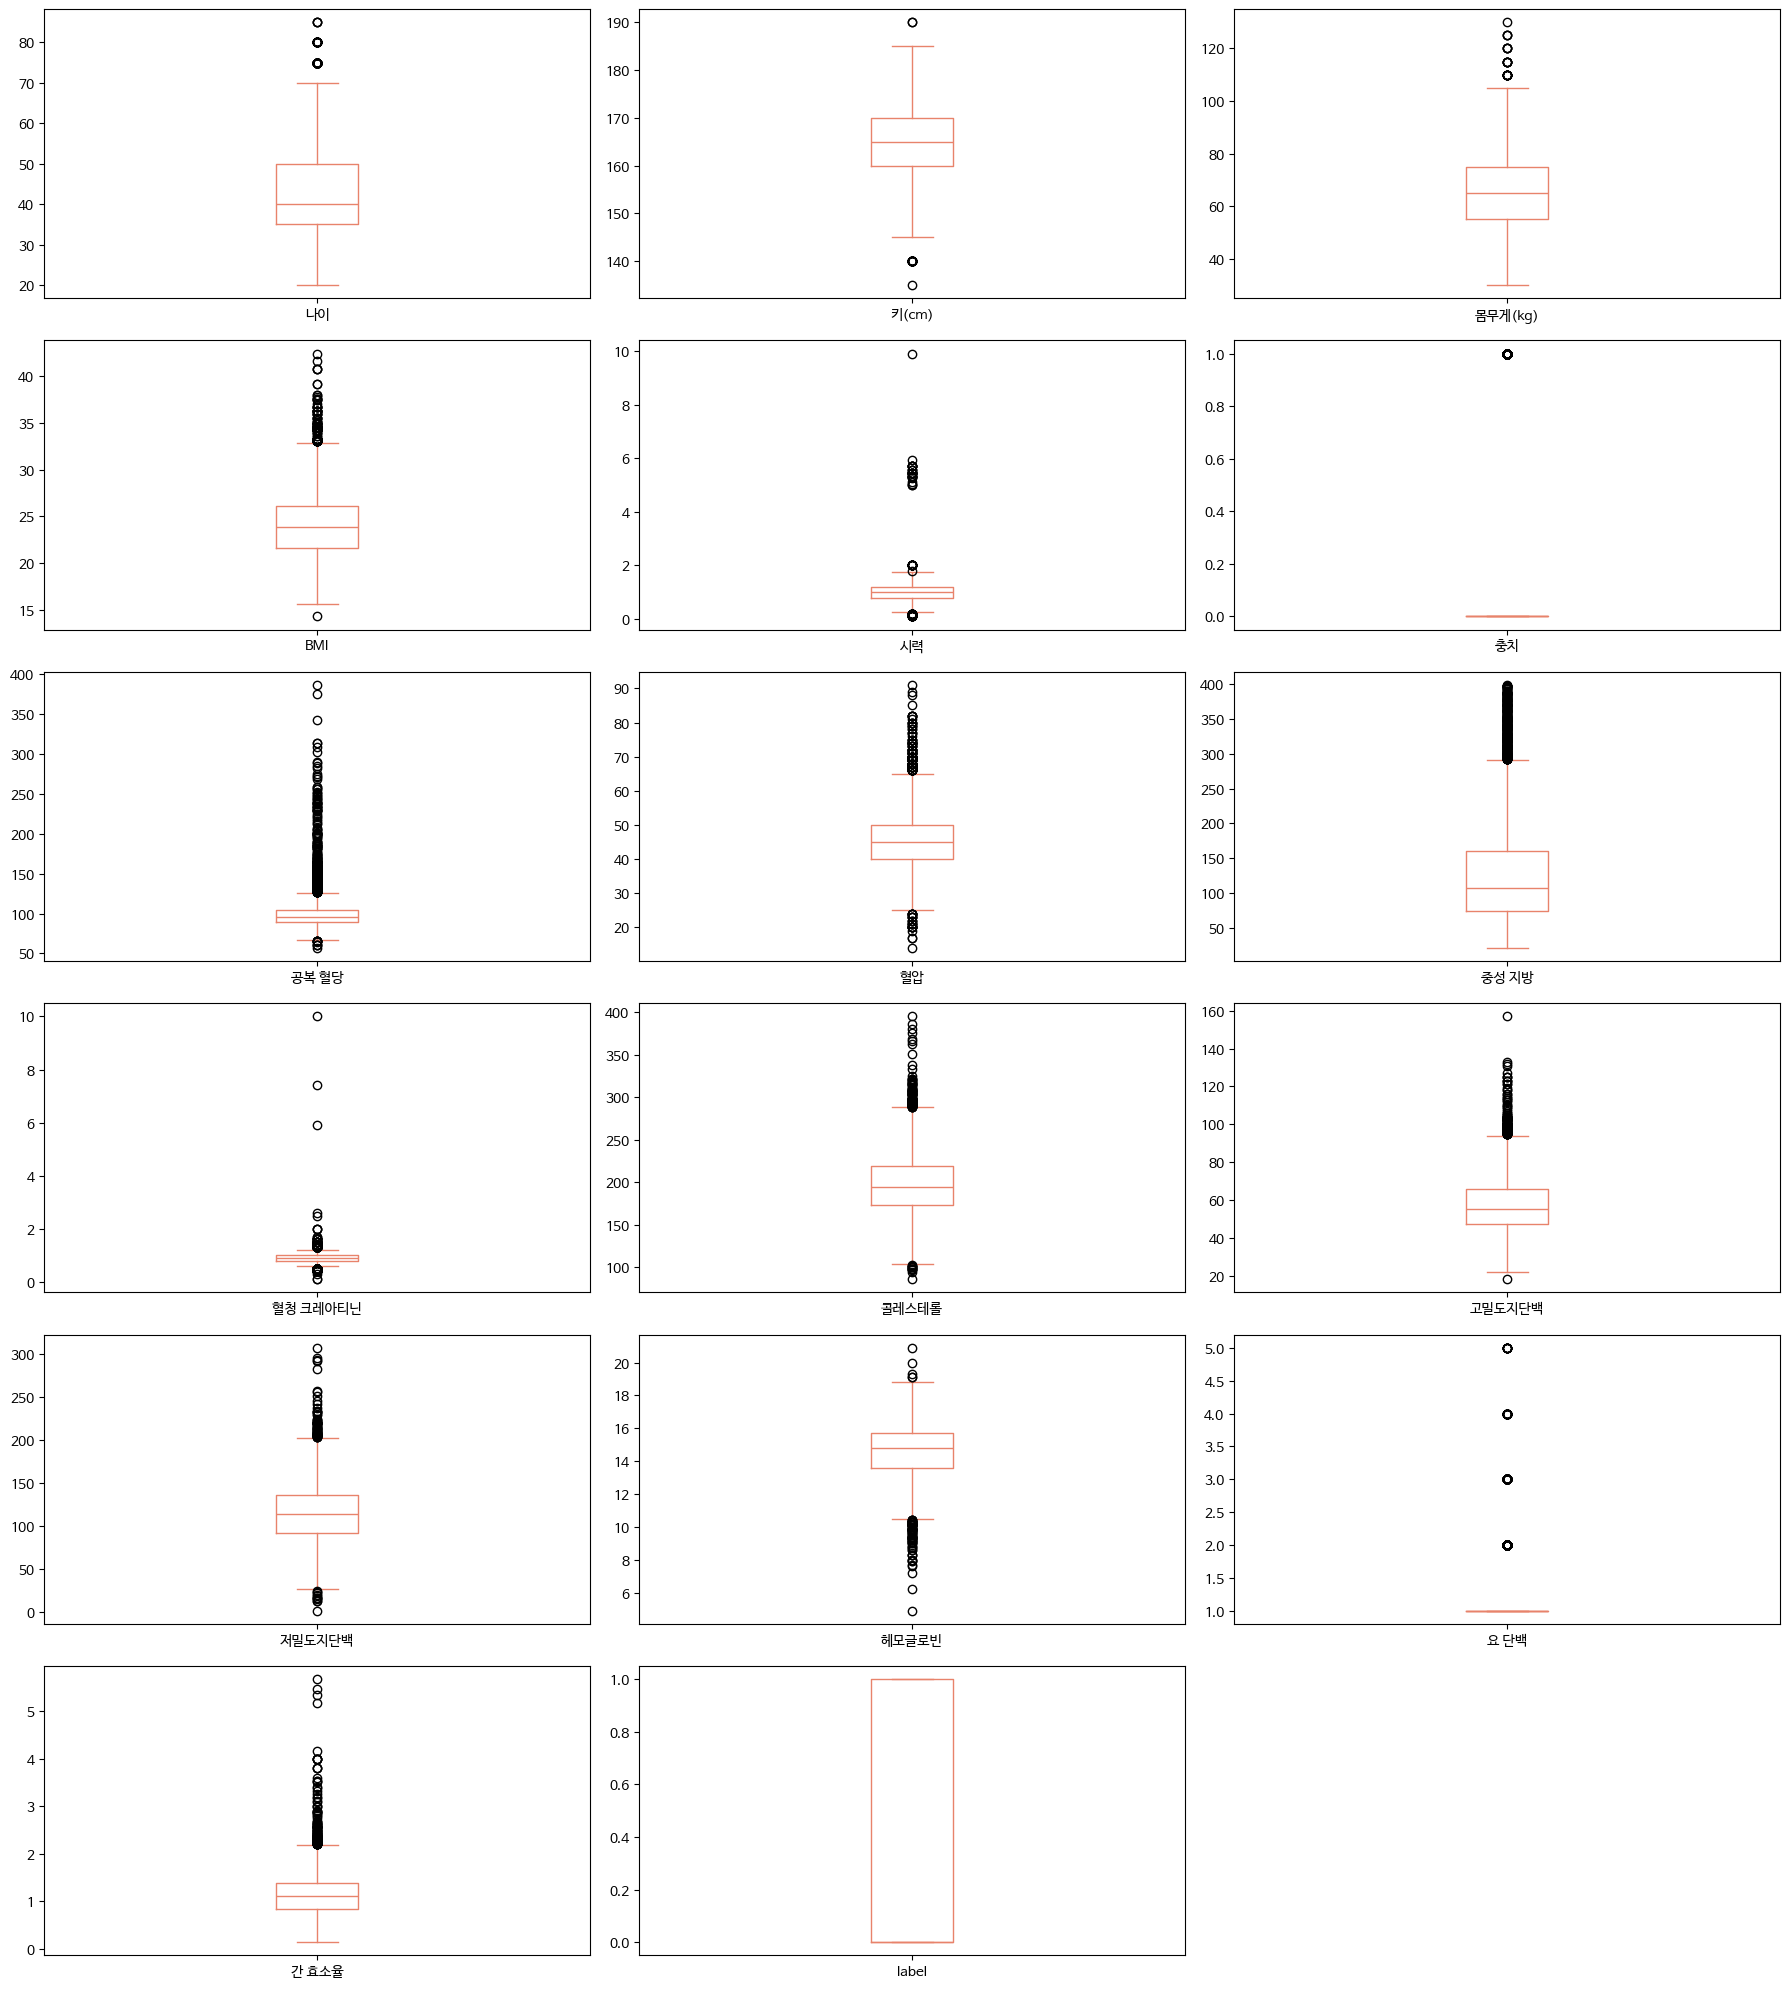

In [ ]:
# 문자열 데이터 등을 제외하고 숫자형 데이터만 골라냅니다.
numeric_data = health_data.select_dtypes(include=['number'])

# 1줄에 3개씩(layout=(6,3)), 박스플롯(kind='box') 그리기
numeric_data.plot(
    kind='box',
    subplots=True,
    layout=(6, 3),
    figsize=(18, 20),
    color='#E8836B'
)

plt.tight_layout()
plt.show()

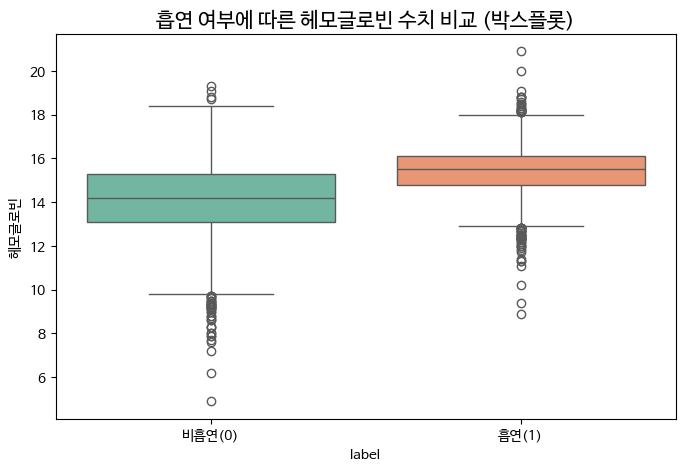

헤모글로빈 수치가

낮을 경우 : 주로 철분 및 영양소 부족, 체내 출혈, 만성 질환 등
12~13 ↓   빈혈, 철결핍성 빈혈, 만성콩팥병, 위장관 출혈 및 골수 질환 등

높을 경우 : 탈수, 흡연, 일산화탄소 노출, 산소 부족 상태(고지대·폐질환)
15~17 ↑   만성 폐 질환, 수면 무호흡증, 신장·간 질환 등


In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='label', y='헤모글로빈', data=health_data, hue='label', palette='Set2', legend=False)
plt.title('흡연 여부에 따른 헤모글로빈 수치 비교 (박스플롯)', fontsize=15)
plt.xticks([0, 1], ['비흡연(0)', '흡연(1)'])
plt.show()

- 헤모글로빈 수치가 <font color="blue">낮을 경우 (12 ~ 13 ↓)</font> :
  - 원인 : 주로 철분 및 영양소 부족, 체내 출혈, 만성 질환 등  
  - 질환 : 빈혈, 철결핍성 빈혈, 만성콩팥병, 위장관 출혈 및 골수 질환 등

- 헤모글로빈 수치가 <font color="red">높을 경우 (15 ~ 17 ↑)</font> :
  - 원인 : 탈수, 흡연, 일산화탄소 노출, 산소 부족 상태(고지대·폐질환)  
  - 질환 : 만성 폐 질환, 수면 무호흡증, 신장·간 질환 등

---
## 6. 이변량 분석
이변량 분석은 두 변수 간의 관계를 탐색하는 과정입니다. 이를 통해 변수들이 서로 어떻게 영향을 주고받는지 파악하고, 주요 예측 변수를 선별할 수 있습니다.

#### 이변량 분석의 목적

-   **변수 간 관계 탐색**: 원인-결과 관계 또는 상호 연관성을 파악합니다.
-   **주요 영향 요인 도출**: 어떤 변수가 목표 변수(예: 흡연 여부)에 가장 큰 영향을 미 미치는지 확인합니다.
-   **예측 모델 Feature 선별**: 향후 예측 모델 구축 시 중요한 특성(Feature) 후보를 선별합니다.

#### 가설 검정 가이드라인

수립한 가설들을 검정하기 위해 변수 유형에 따라 다음 통계 검정 방법을 활용합니다.

  - 유의수준 : 일반적으로 5% (0.05)를 기준으로 합니다.
  - 숫자형 변수 vs 숫자형 변수 : 상관분석 (Correlation Analysis)
  - 범주형 변수 vs 범주형 변수 : 카이제곱 검정 (Chi-squared Test)
  - 범주형 변수 vs 숫자형 변수 : t-검정 (t-test), 분산 분석 (ANOVA)
  - 숫자형 변수 vs 범주형 변수 : 로지스틱 회귀모형을 통해, 회귀계수의 P-value로 검정을 수행합니다.

##### **[TODO] 이변량 분석 수행**

다음 코드 셀에서 수립한 가설들을 바탕으로 이변량 분석을 수행하고, 결과를 해석해 보세요.

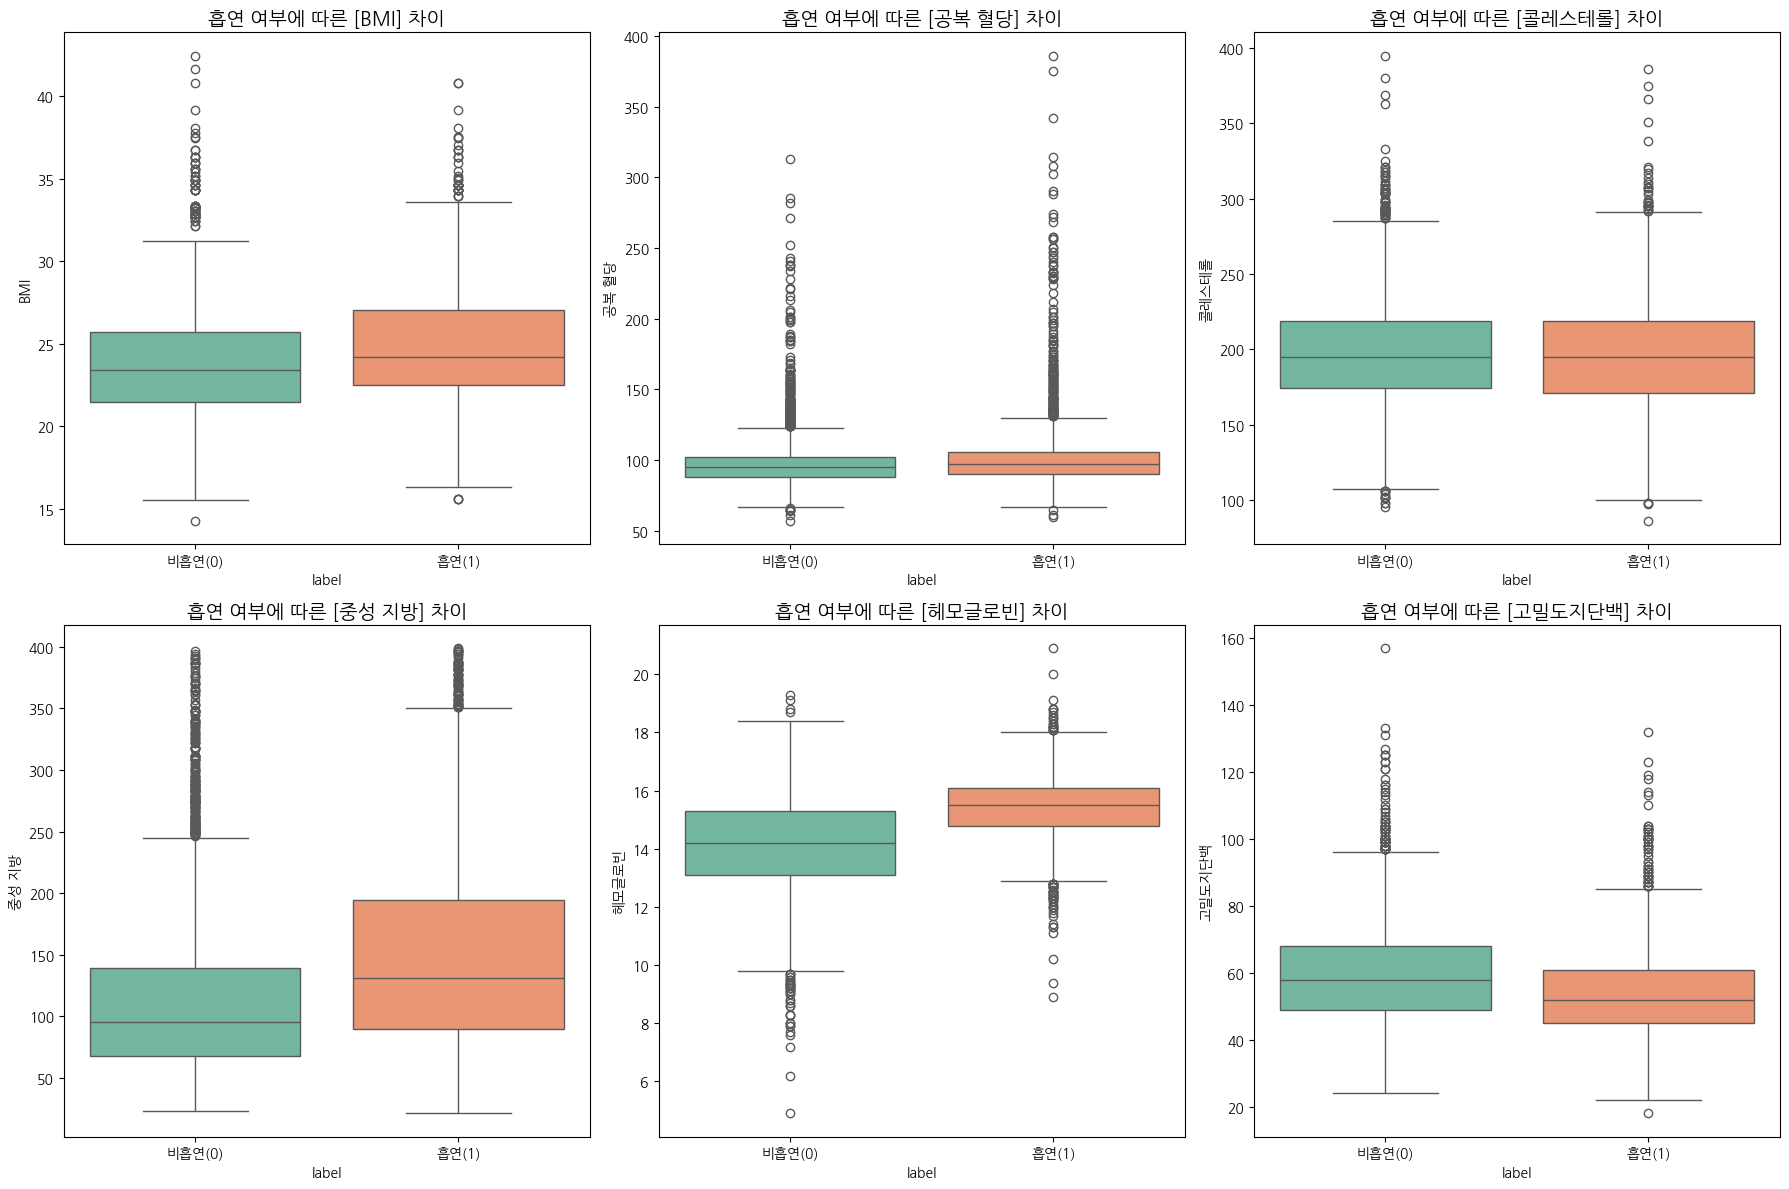


🚬 흡연 여부에 따른 주요 지질 지표 t-검정 결과

[BMI]
 👉 t-statistic = 10.5878
 👉 p-value: 0.0000 (p < 0.05)
 🎯 결과: 귀무가설(H0) 기각
    흡연자와 비흡연자의 BMI 평균은 통계적으로 차이가 있다.

[공복 혈당]
 👉 t-statistic = 8.3798
 👉 p-value: 0.0000 (p < 0.05)
 🎯 결과: 귀무가설(H0) 기각
    흡연자와 비흡연자의 공복 혈당 평균은 통계적으로 차이가 있다.

[콜레스테롤]
 👉 t-statistic = -0.7604
 👉 p-value: 0.4471 (p >= 0.05)
 🎯 결과: 귀무가설(H0) 채택
    흡연자와 비흡연자의 콜레스테롤 평균은 통계적으로 차이가 없다고 볼 수 있다.

[중성 지방]
 👉 t-statistic = 20.0060
 👉 p-value: 0.0000 (p < 0.05)
 🎯 결과: 귀무가설(H0) 기각
    흡연자와 비흡연자의 중성 지방 평균은 통계적으로 차이가 있다.

[헤모글로빈]
 👉 t-statistic = 40.0224
 👉 p-value: 0.0000 (p < 0.05)
 🎯 결과: 귀무가설(H0) 기각
    흡연자와 비흡연자의 헤모글로빈 평균은 통계적으로 차이가 있다.

[고밀도지단백]
 👉 t-statistic = -15.7347
 👉 p-value: 0.0000 (p < 0.05)
 🎯 결과: 귀무가설(H0) 기각
    흡연자와 비흡연자의 고밀도지단백 평균은 통계적으로 차이가 있다.


In [ ]:
from scipy import stats

# 1. 확인할 변수 목록 (오타 '고민도' -> '고밀도' 수정)
cols_to_check = ['BMI', '공복 혈당', '콜레스테롤', '중성 지방', '헤모글로빈', '고밀도지단백']

# 2. 박스플롯 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() # 2차원 배열의 axes를 1차원으로 평탄화


for i, col in enumerate(cols_to_check):
    sns.boxplot(x='label', y=col, data=health_data, ax=axes[i], hue='label', palette='Set2', legend=False)
    axes[i].set_title(f'흡연 여부에 따른 [{col}] 차이', fontsize=14)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['비흡연(0)', '흡연(1)'])

plt.tight_layout()
plt.show()

# 3. t-검정 (통계적 유의성 확인)
print()
print("="*50 + "\n🚬 흡연 여부에 따른 주요 지질 지표 t-검정 결과\n" + "="*50)

for col in cols_to_check:
    # 흡연자와 비흡연자 데이터 분리 (결측치가 있다면 제거하고 계산)
    smoker = health_data[health_data['label'] == 1][col].dropna()
    non_smoker = health_data[health_data['label'] == 0][col].dropna()

    # t-검정 수행 (p-value 계산)
    t_stat, p_val = stats.ttest_ind(smoker, non_smoker, equal_var=False)
    print()
    print(f"[{col}]")
    print(f" 👉 t-statistic = {t_stat:.4f}")
    # p-value가 0.05보다 작으면 통계적으로 유의미한 차이가 있다고 판단

    # 두 집단의 평균이 다르다
    if p_val < 0.05:
        print(f" 👉 p-value: {p_val:.4f} (p < 0.05)")
        print(f" 🎯 결과: 귀무가설(H0) 기각")
        print(f"    흡연자와 비흡연자의 \033[1m{col}\033[0m 평균은 통계적으로 \033[1m차이가 있다.\033[0m")

    # 평균이 다르다고 말할 증거가 부족하다.
    else:
        print(f" 👉 p-value: {p_val:.4f} (p >= 0.05)")
        print(f" 🎯 결과: 귀무가설(H0) 채택")
        print(f"    흡연자와 비흡연자의 \033[1m{col}\033[0m 평균은 통계적으로 \033[1m차이가 없다고 볼 수 있다.\033[0m")

### 🗒️ **<font color="darkgreen">이변량 분석 결과</font>**

- 흡연자와 비흡연자의 신체지표중 유의미할것으로 추정되는 지표를 Boxplot과 t-test로 비교하였습니다.
- 귀무가설 : 아무런 새롭거나 특별한 일이 일어나지 않고 있다는 기본적인 추측
  - 낮은 p값(≤ 0.05) : 해당 결과가 드물게 나타난다는 의미로 따라서 해당 결과가 중요하다고 볼 수 있습니다.
  - 높은 p값(> 0.05) : 해당 결과가 우연에 의해 발생했을 가능성이 높다는 의미입니다.

```
선택 지표 : ['BMI', '공복 혈당', '콜레스테롤', '중성 지방', '헤모글로빈', '고밀도지단백']
```

- 선택 지표 중 콜레스테롤은 p-value가 0.05보다 커 평균에서 크게 차이가 없어 연관성이 미미 하므로, 흡연 여부에 따른 콜레스테롤의 평균 차이는 통계적으로 **유의미하지 않은 것**으로 나타났다.

- 콜레스테롤을 제외한 지표들은 p-value가 0.05보다 작아 귀무가설을 기각하였습니다.  
  따라서 흡연 여부에 따라 통계적으로 **유의미한 차이가 있는 것**으로 나타났습니다.


## 7. 변수 간 상관관계 분석

다양한 건강 지표(숫자형 변수)들 간의 상호 관계를 심층적으로 분석합니다. BMI, 혈압, 혈당, 콜레스테롤 등 여러 지표가 어떻게 서로 연관되어 있는지 파악하여, 개인의 건강 상태를 보다 종합적으로 이해하고 향후 예측 모델 설계에 대한 중요한 통찰을 얻을 수 있습니다.

##### **[TODO] 상관계수 확인 및 HeatMap 시각화**
- `health_data`의 수치형 변수들 간의 상관계수를 계산하고, Heatmap으로 시각화하여 변수 간의 관계를 분석하세요.
  - **Heatmap**: 변수 간의 상관관계(Correlation)를 색상으로 쉽게 확인할 수 있는 시각화 방법입니다. 이를 통해 변수 간 관계를 한눈에 비교하고, 분석에 필요한 주요 변수를 파악할 수 있습니다.

#### 상관 계수 해석 기준:
-   **1에 가까울수록 (강한 양의 상관관계)**: 한 변수가 증가할 때 다른 변수도 함께 증가하는 경향이 매우 강합니다.
-   **-1에 가까울수록 (강한 음의 상관관계)**: 한 변수가 증가할 때 다른 변수는 감소하는 경향이 매우 강합니다.
-   **0에 가까울수록 (약한 상관관계)**: 두 변수 사이에 선형적인 관계가 거의 없거나 매우 약합니다.

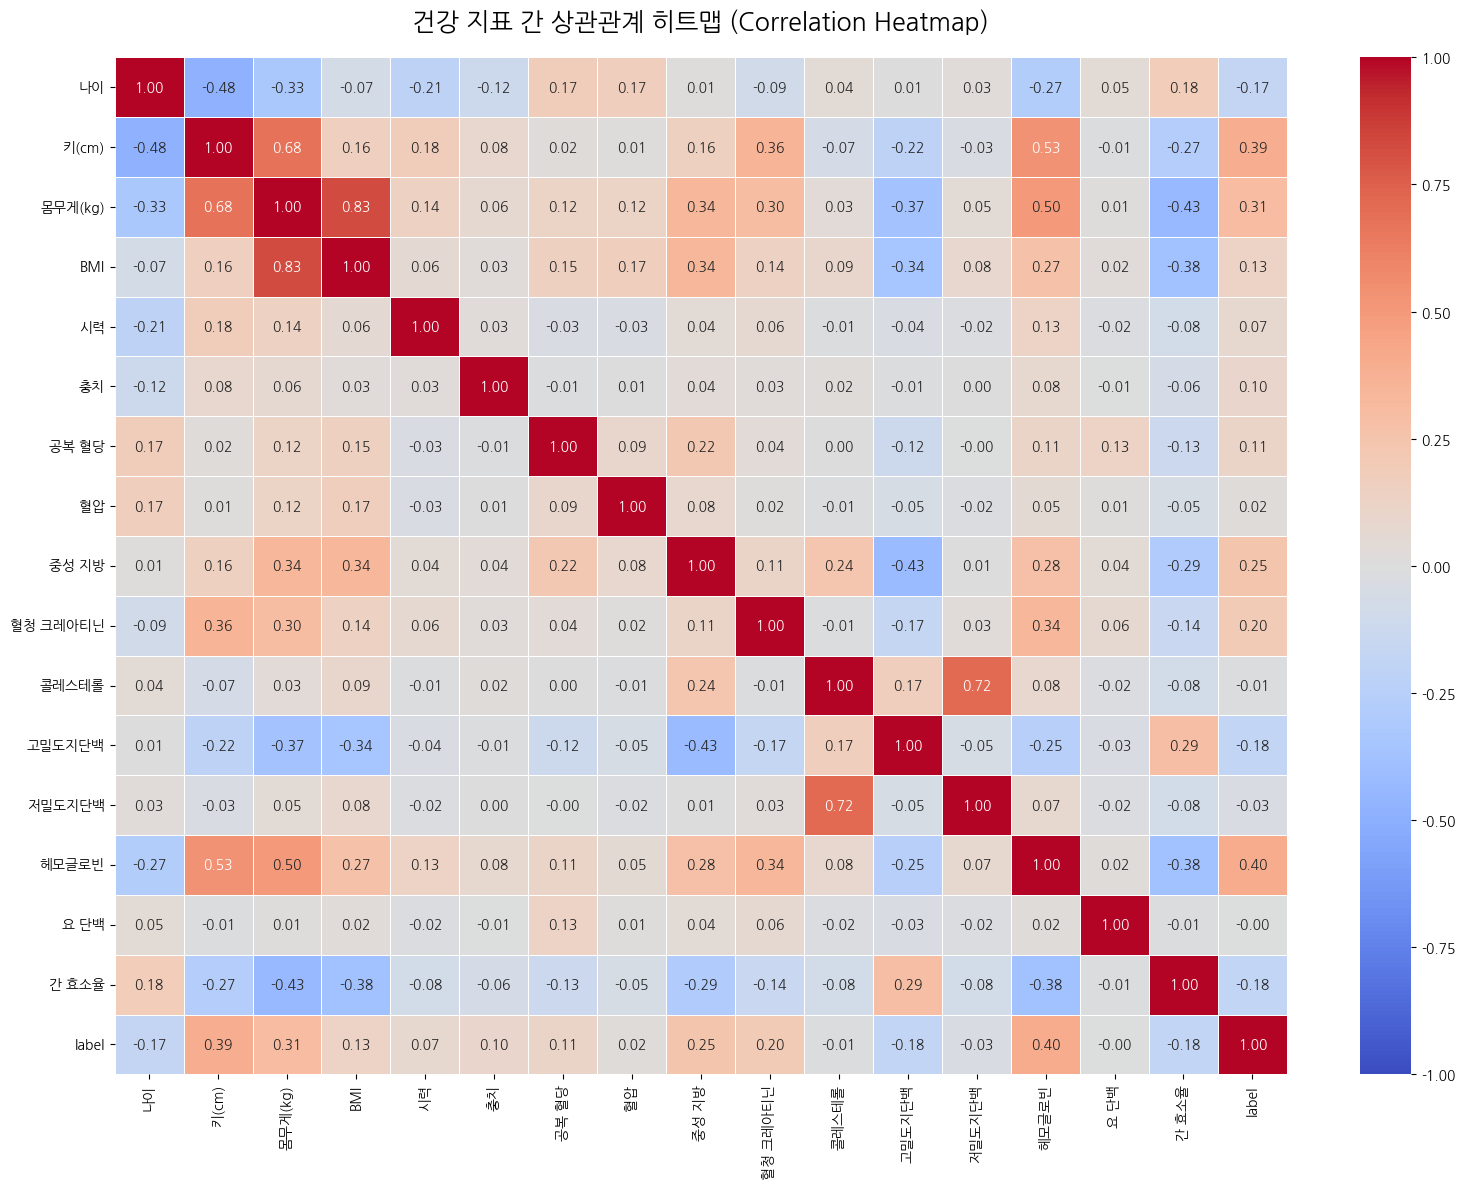

In [ ]:
# 1. 수치형 변수만 선택 (ID, 범주형 데이터 등 문자열 제외)
numeric_df = health_data.select_dtypes(include=['int64', 'float64'])

# 2. 상관계수 계산
corr_matrix = numeric_df.corr()

# 3. 히트맵(Heatmap) 시각화
plt.figure(figsize=(16, 12)) # 그래프 크기 설정

sns.heatmap(corr_matrix,
            annot=True,       # 맵 안에 상관계수 숫자 표시
            fmt='.2f',        # 숫자를 소수점 둘째 자리까지 표시
            cmap='coolwarm',  # 색상 테마 (파란색~빨간색)
            vmin=-1, vmax=1,  # 상관계수의 최소/최대 범위 고정
            linewidths=0.5)   # 셀 사이의 선 굵기

plt.title('건강 지표 간 상관관계 히트맵 (Correlation Heatmap)', fontsize=18, pad=20)
plt.tight_layout()
plt.show()


#### **🔴 강한 관계를 보이는 변수**

1. **`몸무게 ↔ BMI`** : 강한 양의 상관관계 (r = 0.83)  
  → 몸무게가 증가할수록 BMI도 함께 증가

2. **`헤모글로빈 ↔ 요 단백`** : 강한 양의 상관관계 (r = 0.72)  
   → 헤모글로빈 수치가 높을수록 요 단백 수치도 증가
   두 수치가 직접적으로 비례하여 증가한다는 보편적인 의학적 인과관계는 없지만, 고혈압이나 당뇨 등 전신 질환이 있는 경우 각각의 수치에 복합적인 영향이 나타날 수는 있을 것으로 보입니다.  

3. **`label(흡연여부) ↔ 헤모글로빈`** (0.40)  
  → 앞서 분석했던 대로, 흡연 여부와 헤모글로빈 수치는 양의 상관관계를 가집니다.(흡연자일수록 수치가 높음)

4. 기타
  - 키와 몸무게(0.68), 키와 헤모글로빈(0.53), 몸무게와 헤모글로빈(0.50) 등이 비교적 높은 양의 상관관계를 보였지만, 일반적으로 강한 **상관관계 기준인 |r| ≥ 0.7**에는 미치지 못했습니다.
  - 그럼에도 키와 몸무게가 클수록 헤모글로빈 수치 역시 높아지는 일관된 경향을 확인할 수 있었습니다. 키와 몸무게가 헤모글로빈 수치 증가의 직접적인 원인이라고 보기는 어려우나, 비만일수록 헤모글로빈 수치가 높아진다는 기존 연구 결과를 고려할 때 체중 관리의 중요성을 시사하는 대목입니다.


#### **⚪ 약한 관계를 보이는 변수**

1. `요단백 ↔ 대부분의 다른 건강 지표들`  
 요단백 행을 보면 키(-0.01), 몸무게(0.01), 혈압(0.01), 헤모글로빈(-0.05) 등 대부분의 수치가 0에 매우 가깝습니다.  
 즉, 요단백 수치는 다른 일반적인 신체 지표들과는 큰 상관관계가 없는 것으로 보입니다.  

2. `label(흡연여부)` ↔ `콜레스테롤(-0.01), 혈압(0.02), 시력(0.07)`  
  흡연 여부는 콜레스테롤이나 혈압, 시력 자체와는(데이터상으로는) 직접적인 선형 상관관계가 거의 나타나지 않습니다.

3. `나이 ↔ 공복 혈당`(0.01), `시력 ↔ 혈청 크레아티닌`(-0.01), `충치 ↔ 혈압`(0.03), `abel(흡연여부) ↔ `청 크레아티닌`(-0.00)  
위 변수들은 상관계수가 0에 가까워 서로 선형적인 관계가 거의 없는 것으로 볼 수 있습니다.

## 8. 결론 및 인사이트 도출

지금까지의 데이터 분석 과정을 통해 흡연 여부와 관련된 건강 지표들 간의 관계를 탐색했습니다. 이제 이 모든 분석 결과를 종합하여 핵심적인 결론과 인사이트를 도출해 보세요.

##### **[TODO] 흡연 여부와 관련성 높은 요인 인사이트 제시**
- 종합 분석 결과와 가설 검정 결과를 바탕으로, 어떤 요인(변수)이 흡연 여부와 관련성이 높은지 인사이트를 제시하세요.

**(예시)**
- 흡연자는 비흡연자에 비해 평균 혈압과 중성지방 수치가 유의하게 높았습니다.(p<0.05)
- 반면, BMI는 유의한 차이가 없었습니다. (p>0.05)
- 따라서 흡연은 대사 관련 지표(혈압, 중성지방)에 더 큰 영향을 미치는 것으로 해석할 수 있습니다.

### 🚬 <font color="navy">흡연 여부와 관련성 높은 지표들</font>

> 지표 모두 t-test 결과 p-value < 0.05로, 흡연 여부에 따른 차이가 뚜렷했습니다.


> **📌 헤모글로빈 > 중성지방 > 고밀도지단백(HDL), 공복혈당**


| 변수 | 흡연군 평균 | 비흡연군 평균 | 평균 차이 | 변화율(%) | 해석 |
|---|---|---|---|---|---|
| 헤모글로빈 | 15.45 | 14.16 | **+1.29** | **+9.1%** | 가장 큰 변화율, 만성 저산소 보상반응과 일치 |
| 중성지방 | 150.79 | 113.22 | **+37.57** | **+33.2%** | 변화율 가장 큼, 지질대사 이상 |
| 고밀도지단백(HDL) | 53.91 | 59.35 | -5.44 | -9.2% | "좋은 콜레스테롤" 감소, 잘 알려진 패턴 |
| 공복 혈당 | 102.35 | 97.50 | +4.85 | +5.0% | 흡연군이 뚜렷하게 더 높음 (인슐린 저항성 증가 패턴과 일치) |

```
# 변화율(%) = 차이 / 비흡연군 평균 × 100
```

1. **헤모글로빈** (높은 연관성)
-  비교적 높은 양의 상관관계(r=0.40)를 보여 주요한 관련 변수로 확인되었고, 수치가 높은(상위 25%) 사람의 비율이 흡연군에서 더 높았습니다.  
- 흡연군 중앙값(≈15.44)이 비흡연군(≈14.2)보다 뚜렷하게 높고(d=0.91), 두 박스가 거의 겹치지 않습니다.
  - 🩺  흡연으로 인한 체내 저산소 상태를 극복하기 위해 몸에서 헤모글로빈 생성을 강제로 늘립니다.  
이는 혈액의 점도를 높여 심혈관 질환 위험을 가중시키는 직접적인 원인이 됩니다.

2. **중성지방**
- 약한 양의 상관관계(r=0.24)를 보여 주요한 관련 변수로 확인되었고, 수치가 높은(≥150) 사람의 비율이 흡연군에서 더 높았습니다.
- 평균값 : 흡연군(150.82)이 비흡연군(113.20)보다 높습니다.
- 이상치가 두 그룹 다 많지만 흡연군 쪽 중앙값 자체가 확연히 높아, 지질대사 이상과 흡연의 연관성을 보여주었습니다.
- 🩺  담배의 니코틴 성분은 교감신경을 자극하여 체내 지방 대사에 교란을 일으킵니다. 이로 인해 저장되어 있던 지방이 분해되어 혈액 속으로 유입되면서 혈중 중성지방 수치가 상승하게 됩니다.
- 혈액 내 중성지방이 늘어나면 피가 끈적해지고 혈관 벽에 찌꺼기가 쌓이기 쉬워져, 동맥경화 및 심혈관 질환의 강력한 원인이 됩니다.

3. **고밀도지단백(HDL)**
- 약한 양의 상관관계(r=0.18)를 보여 주요한 관련 변수로 확인되었고, 수치가 낮은(<40) 사람의 비율이 흡연군에서 더 높았습니다.
- 중앙값 : 흡연군이 비흡연군보다 아래에 있고, 박스가 전반적으로 낮게 형성
- 평균값 : 흡연군(53.91)이 비흡연군(59.35)보다 낮습니다.
- 🩺 * 흡연이 "좋은 콜레스테롤"로 불리는 HDL을 낮춘다는, 심혈관 위험 관점에서 잘 알려진 관계가 확인됩니다.

4. **공복 혈당**
- 약한 양의 상관관계(r=0.11)를 보여 주요한 관련 변수로 확인되었고, 수치가 높은(>100) 사람의 비율이 흡연군에서 더 높았습니다.
- 중앙값: 흡연군(97.00)이 비흡연군(95.00)보다 높으며, 데이터가 밀집된 박스(IQR) 전체가 비흡연군에 비해 전반적으로 높게 형성되어 있습니다.
- 변동성 및 이상치: 두 그룹 모두 정상 범위를 넘어 혈당이 매우 높은 이상치가 다수 존재하나, 흡연군의 데이터 변동성(IQR 폭)이 상대적으로 더 큽니다.
  - **흡연과 공복 혈당** (인슐린 저항성 악화)  
 🩺 담배의 독성 물질이 인슐린 저항성을 유발해 공복 혈당을 높입니다. 낮은 BMI로 인해 안심하기 쉽지만, 실제로는 당뇨 발병 위험을 30~50%까지 높이는 핵심 원인입니다.
  - **흡연과 BMI** ('겉보기 체중'의 착시)  
 🩺 흡연 시 니코틴 작용으로 식욕을 억제되서 기초대사량을 일시적으로 높여 흡연자의 평균 BMI는 낮아지지만, 코르티솔(스트레스 호르몬) 분비 증가로 인해 복부 내장 지방이 축적되는 '마른 비만' 위험이 큽니다.